![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# Single-Species Single-Season Occupancy Model - Practical

Author details: Xiang Zhao, Dr Zachary Amir

Editor details: Dr Zachary Amir

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons and WildObs team. Please refer to the EcoCommons website for more details: https://www.ecocommons.org.au/

For more information about WildObs, please visit [https://wildobs.org.au](https://wildobs.org.au/#about) and <https://github.com/WildObs>

Date: Feb 2026

# Script information

There are two notebooks about Single-Species Single-Season Occupancy Model, one is conceptual ([click here to learn more](https://ecocommonsaustralia.github.io/notebook-blog/notebooks/Occupancy/EC_Occupancy_conceptual.html)), and another is practical. This one is the **practical** notebook which gives a brief introduction to the concepts of Single-Species Single-Season Occupancy Model with some simulated data.

This notebook, developed by the EcoCommons and WildObs team, showcases how to build Single-Species Single-Season Occupancy Model with camera trapping data with "unmarked" R package ([click here to learn more](https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/2041-210X.14123)).

## Other file formats of this notebook

| Notebook | Files | Open in Colab / ARDC Jupyter | DOI |
|:---:|:---:|:---:|:---:|
| Single-Species Single-Season Occupancy Model - Practical | <a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_practical.ipynb"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/jupyter_notebook.png" width="40%"></a>&nbsp;&nbsp;<a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_practical.qmd"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/quartomd.png" width="40%"></a> | [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_practical.ipynb) | [![DOI](https://img.shields.io/badge/DOI-10.5281%2Fzenodo.19552244-blue)](https://doi.org/10.5281/zenodo.19552244) |

# Introduction

Occupancy models provide a powerful framework for estimating where species occur while accounting for imperfect detection — a common challenge in wildlife research. Camera traps are particularly well suited to this task because they generate repeated detection–non-detection data that can be structured into the hierarchical models implemented in the **unmarked** R package.

Single-species, single-season *abundance* models that account for imperfect detection can also be calculated in the **unmarked** R package using much of the same approach described here, and these models are known as [N-Mixture models](https://www.rdocumentation.org/packages/unmarked/versions/1.5.1/topics/pcount). The key distinction is that abundance models use count data to estimate a species' abundance rather than detection–non-detection data. However, the assumptions of N-Mixture models are easily violated and requires careful interpretation (See [Link et al., 2018](https://doi.org/10.1002/ecy.2362) & [Nakashima, 2020](https://doi.org/10.1002/1438-390x.12028) to learn more). This practical notebook demonstrates how to build a **single-species, single-season occupancy model** using camera-trap data curated and standardised through the **Wildlife Observatory of Australia (WildObs)** platform. WildObs processes raw camera-trap images using artificial intelligence (e.g., [MegaDetector](https://github.com/agentmorris/MegaDetector), [SpeciesNet](https://github.com/google/cameratrapai), and bespoke regional computer vision models, such as our first [model from the Wet Tropics of QLD](https://huggingface.co/WildObs/WildObs_QLD_WetTropics)), employs the [CamtrapDP data standard](https://camtrap-dp.tdwg.org/), and provides harmonised tables describing [deployments](https://camtrap-dp.tdwg.org/data/#deployments), [observations](https://camtrap-dp.tdwg.org/data/#observations), [media](https://camtrap-dp.tdwg.org/data/#media), and range of spatial and temporal covariates that are ready for ecological analysis.

# Wildlife Observatory of Australia

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/wildobslogo_withanimal.png)

Wildlife Observatory of Australia - Australia’s national platform for processing and sharing wildlife camera data. WildObs will transform how Australia handles wildlife camera data by creating a national platform powered by AI. It will streamline biodiversity monitoring, break down data silos, and support effective conservation strategies by providing researchers and policymakers with easy access to consistent, high-quality data for informed decision-making. The WildObs researcher network is supported by Australia's National Research Infrastructure. TERN supports the field observatory and standard protocols, ALA hosts the tagged image repository and ARDC Planet Research Data Commons, through QCIF, is building a user-friendly data management and access platform.

For more information about WildObs, please visit [https://wildobs.org.au](https://wildobs.org.au/#about) and <https://github.com/WildObs>

# WildObsR R package

[![R Package](https://img.shields.io/badge/R-package-blue.svg)](#)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](#)
[![Codecov test coverage](https://codecov.io/gh/WildObs/WildObsR/graph/badge.svg)](#)

> Professional tools for camera trap data access, management, and analysis in R

WildObsR provides a comprehensive suite of functions for processing, standardizing, and analyzing wildlife camera trap data. Built to support the [Camera Trap Data Package (camtrap DP)](https://camtrap-dp.tdwg.org/) data standard and [Frictionless Data](https://specs.frictionlessdata.io/data-package/) specifications, this package streamlines workflows from raw observations to publication-ready analyses. Camtrap DP is a is a community-developed data exchange format for camera trap data, which enhances interoperability with other R packages and functions, such as with the [camtrapdp R package](https://inbo.github.io/camtrapdp/), [camtraptor R package](https://inbo.github.io/camtraptor/), and [camtrapR R package](https://jniedballa.github.io/camtrapR/index.html).

For more information of this R package, please visit <https://github.com/WildObs/WildObsR>

# Objectives

-   Install WildObsR R package

-   Download and inspect WildObs camera-trap projects using `WildObsR::wildobs_mongo_query()` & `WildObsR::wildobs_dp_download()`

-   Inspect and prepare site-level and observation-level covariates

-   Spatially resample deployments & covariates into biologically meaningful sampling units using `WildObsR::spatial_hexagon_generator()` & `WildObsR::resample_covariates_and_observations()`

-   Construct detection history matrices using `WildObsR::matrix_generator()`

-   Build the unmarkedFrameOccu (UMF) object using `unmarked::unmarkedFrameOccu`

-   Fit occupancy models using `unmarked::occu()`, compare competing models to determine the top model, and then visualize & interpret the results

# **Workflow Overview**

| Notebooks | Main Content | Sub-content |
|-----------|-------------|-------------|
| **Single-Species Single-Season Occupancy Model - Conceptual** | Overview and Conceptualisation | 1.1 What is Occupancy modelling? |
| | | 1.2 Single-species, single-season occupancy model and assumptions |
| | | 1.3 Single-species, single-season occupancy model with covariates |
| **Single-Species Single-Season Occupancy Model - Practical (this notebook)** | Occupancy model with camera traps | 1.1 Camera Trap |
| | | 1.2 Camera trap surveys in Queensland's Wet Tropics 2022–2023 |
| | | 1.3 How to prepare camera trap data for occupancy model |
| | | 1.4 Occupancy model with WildObs data |

In the near future, this material may form part of comprehensive support materials available to EcoCommons users. If you have any corrections or suggestions to improve the efficiency, please [contact the EcoCommons](mailto:support@ecocommons.org.au) team.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

# Set-up: R Environment and Packages

Some housekeeping before we start. This process might take some time as many packages needed to be installed.

## S.1 Set the working directory and create a folder for data.

Save the Quarto Markdown file (.QMD) to a folder of your choice, and then set the path to your folder as your working directory.


::: callout-important
## Modifications made to run this notebook (2026-08-24)

Updated to reflect **WildObsR 0.2.0** and the current Camtrap DP / WildObs observations schema. The observation timestamp columns were renamed from `observationStart`/`observationEnd` to **`eventStart`/`eventEnd`**; the old columns no longer exist in the downloaded data (and WildObsR 0.2.0 expects the new names internally). The `convert_time` chunk was updated accordingly. `frictionless` already returns these columns as `POSIXct`. The API key is now read from the environment (`Sys.getenv("WILDOBS_API_KEY")`). No analytical logic was changed.
:::

In [1]:

# Set the workspace to the current working directory
# Uncomment and replace the path below with your own working directory if needed:
# setwd("/Users/zhaoxiang/Documents/tmp/EC_GLM_notebook")

workspace <- getwd()  # Get the current working directory and store it in 'workspace'

# Increase the plot size by adjusting the options for plot dimensions in the notebook output
options(repr.plot.width = 16, repr.plot.height = 8)  # Sets width to 16 and height to 8 for larger plots



## S.2 Install and load essential libraries.

Install and load R packages.


In [2]:

# Set CRAN mirror
options(repos = c(CRAN = "https://cran.rstudio.com/"))

## load libs
# WildObsR        for accessing WildObs data and bespoke data wrangling function
# frictionless    for working with frictionless data packages and extracting data resources
# unmarked        for running frequentist occupancy and/or abundance models

# Required packages
packages <- c("unmarked", "ggplot2", "plyr", "dplyr", "frictionless", "tidyverse", "janitor", "knitr", "leaflet", "htmltools", "MuMIn", "remotes")


# Install any missing packages
for (pkg in packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
  library(pkg, character.only = TRUE)
}

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”


Warning message:
“package ‘dplyr’ was built under R version 4.5.2”



Attaching package: ‘dplyr’




The following objects are masked from ‘package:plyr’:

    arrange, count, desc, mutate, rename, summarise, summarize




The following objects are masked from ‘package:stats’:

    filter, lag




...

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::arrange()   masks plyr::arrange()
✖ purrr::compact()   masks plyr::compact()
✖ dplyr::count()     masks plyr::count()
✖ dplyr::desc()      masks plyr::desc()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::mutate()    masks plyr::mutate()
✖ dplyr::rename()    masks plyr::rename()
✖ dplyr::summarise() masks plyr::summarise()
✖ dplyr::summarize() masks plyr::summarize()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Warning message:
“package ‘knitr’ was built under R version 4.5.2”


Warning message:
“package ‘htmltools’ was built under R version 4.5.2”



## S.3 WildObsR R package

[![R Package](https://img.shields.io/badge/R-package-blue.svg)](https://www.r-project.org/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT) [![Codecov test coverage](https://codecov.io/gh/WildObs/WildObsR/graph/badge.svg)](https://app.codecov.io/gh/WildObs/WildObsR)

WildObs stores all spreadsheets of camera trap data in a remote [MongoDB database](https://www.mongodb.com/), which enables remote downloads of both new and legacy camera trap data ready for analysis. This is achieved through two key functions: `WildObsR::wildobs_mongo_query()` & `WildObsR::wildobs_dp_download()`.

-   The first function (`WildObsR::wildobs_mongo_query()`) allows you to query the WildObs database for camera trap projects matching specific spatial, temporal, taxonomic, contributor, sampling design, and/or data-sharing criteria. This function produces a vector of camera trap projectIDs that are available for download using the second function.
-   The second function (`WildObsR::wildobs_dp_download()`) is a data package download function that connects to the WildObs MongoDB server, retrieves project-specific metadata and data resources, and bundles them into Frictionless Data Packages formatted using the camtrap DP data standard.

As WildObs continues to update their MongoDB database with new data, re-running the same query may provide additional camera trap data projects through time. However, WildObsR's other functionality (e.g., `WildObsR::matrix_generator()`) is frequently updated. Thereofre, please use the below function to keep your WildObsR R package the most updated version.


In [3]:


# Install WildObsR from GitHub (WildObs/WildObsR)
# This installer avoids GitHub tokens by installing directly from a public tarball.
# It is suitable for workshops, teaching notebooks, and CI environments.

install_or_update_WildObsR <- function(ref = "main") {
  
  if (!requireNamespace("WildObsR", quietly = TRUE)) {
    message("WildObsR not found. Installing from GitHub...")
    
    install.packages(
      sprintf(
        "https://github.com/WildObs/WildObsR/archive/refs/heads/%s.tar.gz",
        ref
      ),
      repos = NULL,
      type = "source"
    )
    
    message("WildObsR installed successfully.")
  } else {
    message("WildObsR is already installed. Skipping installation.")
  }
  
  invisible(TRUE)
}

# Run the install process
install_or_update_WildObsR()

# Note:
# - This installation method does not require a GitHub Personal Access Token.
# - Installation time depends on your R environment and which dependencies
#   are already installed. The first installation may take longer.

# Note:
# - This installation method does not require a GitHub Personal Access Token.
# - Installation time depends on your R environment and which dependencies
#   are already installed. The first installation may take longer.

WildObsR is already installed. Skipping installation.




# 1 Occupancy model with camera traps

## 1.1 Camera Traps

Camera traps are widley used in wildlife research and monitoring due to their logistical advantages such as low labour intensity, low cost, and long temporol coverage. As a result, camera trap survey are increasingly generating high resolution data sets spanning individual regions ([Anderson et al., 2025](https://doi.org/10.1002/ece3.71464)) to entire continents ([Bruce et al., 2025](https://doi.org/10.1111/brv.13152)).

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/A_flowchart_digital_illustration_in_a_scientific_d.png)

**Figure 1. Key components of occupancy modelling with camera trap.** A species may be present at a site (occupancy, ψ), but detection is imperfect. Camera traps provide repeated detection events, producing detection/non-detection histories that allow estimation of both occupancy (ψ) and detection probability (*p*).

## 1.2 **Camera trap surveys in Queensland's Wet Tropics 2022-2023**

This data was collected by Dr Zachary Amir and the Ecological Cascades Lab at the University of Queensland to study interactions between native and invasive vertebrates in North Queensland's Wet Tropics Rainforests. The camera trap surveys conducted here complement and extend prior surveys conducted by Dr. Tom Bruce as part of his PhD research studying feral cats in North Queensland forests. Important to note that these surveys implemented paired camera deployments, where each sampling location received a camera placed on the road and another camera placed 50 m into the bush. Sampling locations were typically spaced 1km apart from each other, though this varies between small and large landscapes.

This dataset has been published with the Atlas of Living Australia ([ALA](https://www.ala.org.au/)) through the CamtrapDP data exchange format [https://camtrap-dp.tdwg.org](https://camtrap-dp.tdwg.org/)/) and transformed into a [Darwin Core](https://dwc.tdwg.org/) dataset. You can access the occurrence records from this dataset [here](https://collections.ala.org.au/public/show/dr31594) and you can access a curated selection of camera trap images from this survey hosted on the ALA [here](https://images.ala.org.au/?criteria=b0f703bb-8cb5-48ea-b5fd-b7bf0ee51d22&fq=dataResourceUid:dr31594).

## 1.3 How to prepare camera trap data for occupancy models

WildObs is developing an online Wildlife Image Management Platform powered by [Agouti](https://www.agouti.eu/) to enable researchers to use computer vision AI models to rapidly convert camera trap media (*i.e.*, images and/or videos) into spreadsheets. These spreadsheets are standardized and harmonized by WildObs and incorporated into WildObs's database and accessible via the WildObsR package. The WildObs image managment platform is still in development, but if you are interested in being an early tester or receiving updates about WildObs's development, [please complete this form to be added to the WildObs contact list](https://forms.office.com/pages/responsepage.aspx?id=U2DyzCOQzkaeHR83GasKQBuMFNE6uh1On8rg5yzIQ5tUQzBIUzVKUjhVWjFSMjJVT1lTVllWQUk5WiQlQCN0PWcu&route=shorturl).

Here we just give a brief the summary points of what we had done:

### 1.3.1 Query WildObs MongoDB for Relevant Project IDs and Download Projects

**Step 1:** All raw camera trapped images have had their wildlife classified by humans or with computer vision models including detection models like MegaDetector and classifiers like SpeciesNet, to generate species identifications. The images generated in this data were classified by the [Wildlife Insights's SpeciesNet computer vision model](https://www.wildlifeinsights.org/about-wildlife-insights-ai) and identifications were manually verified and corrected if necessary by humans.

We will access the relevant camera trap project we want using the two functions `WildObsR::wildobs_mongo_query()` & `WildObsR::wildobs_dp_download()`.

**WildObsR::wildobs_mongo_query function**

This function queries the WildObs MongoDB database for projects matching specified spatial, temporal, taxonomic, contributor, and data-sharing criteria. It extracts metadata from the database and filters projects based on bounding box overlaps, temporal overlaps, species detected, contributors associated, matched sampling designs, and data sharing preferences. The function also ensures that only projects that have past their embargo date are shared.


In [4]:

# Load libraries
library(WildObsR)
library(frictionless)  ## For working with data packages

# Read your personal WildObs API key from the environment.
# Set it before running, e.g. in ~/.Renviron:  WILDOBS_API_KEY=your-key
api_key <- Sys.getenv("WILDOBS_API_KEY")

# Query projects in Queensland from 2020-2024
spatial_query <- list(xmin = 145.0, xmax = 154.0, ymin = -29.0, ymax = -10.0)
temporal_query <- list(minDate = as.Date("2020-01-01"),
                       maxDate = as.Date("2024-12-31"))
# run the query
project_ids <- wildobs_mongo_query(
  api_key = api_key,
  spatial = spatial_query,
  temporal = temporal_query,
  tabularSharingPreference = c("open", "partial")
)

project_ids

[1] "QLD_Chital_Quinn_2022-2024_WildObsID_0011"              
[2] "QLD_Dwyers_Scrub_ANIM3018_2023_WildObsID_0005"          
[3] "QLD_Feral_Pigs_Lana_Harriott_2022-2024_WildObsID_0029"  
[4] "QLD_Kgari_BIOL2015_2023-24_WildObsID_0004"              
[5] "QLD_Kgari_potoroos_Amir_2022_WildObsID_0003"            
[6] "QLD_Paluma_cassowary_Mclean_2023-24_WildObsID_0006"     
[7] "QLD_SE_QLD_Fire_Maitz_2021-2022_WildObsID_0043"         
[8] "QLD_Wet_Tropics_feral_cats_Bruce_2019-20_WildObsID_0007"
[9] "ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001"


**ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001**

Out of the 5 projects listed above, we are going to use "ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001" for this notebook.

**WildObsR::wildobs_dp_download()**

This function connects to the WildObs MongoDB server, retrieves project-specific metadata and data resources, and bundles them into Frictionless Data Packages formatted using the camtrap DP data standard. Note, while neither the db_url or api_key parameters are required, the function will return an error if at least one of these parameters are not provided.


In [5]:

project_ids <- project_ids[project_ids == "ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001"]

# Download data packages
dp_list <- wildobs_dp_download(
  api_key = api_key,
  project_ids = project_ids,
  media = FALSE,              # We don't need media files for this notebook, and they are slow to download
  metadata_only = FALSE
)


**dp_list** is list object containing the single data package specified in `project_ids`, though it could contain multiple projects. The data packages are formated in **camtrap DP**.


In [6]:

class(dp_list)

class(dp_list[[1]])

dp_list[[1]]

[1] "list"

[1] "camtrapdp"   "datapackage" "list"

,deploymentID,locationID,locationName,latitude,longitude,coordinateUncertainty,deploymentStart,deploymentEnd,setupBy,cameraID,⋯,detectionDistance,timestampIssues,baitUse,featureType,habitat,deploymentGroups,deploymentTags,deploymentComments,multiSeason_deploymentGroup,projectName
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dttm>,<dttm>,<chr>,<chr>,⋯,<dbl>,<lgl>,<lgl>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CFRAG_01_WildObsID_0001_2022_Cam1,CFRAG_01_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.29114,145.6316,1,2022-12-15 08:52:45,2023-02-15 10:46:32,ZA SK,2065144,⋯,NA,FALSE,FALSE,NA,tropical rainforest,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,lure: none | predatorManagement: No management,Swapped low NIMH batteries for alkaline. Access behind large tree fall gap after following water pipes. & SD card = 34A & physical ID on cam = 7 working cam & had these animal signs: Bird calls & animal signs are: Bird calls,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001
2,CFRAG_01_WildObsID_0001_2022_Cam2,CFRAG_01_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.29114,145.6316,1,2022-12-15 08:19:27,2023-03-06 13:29:49,ZA SK,2065144,⋯,NA,FALSE,FALSE,trailHiking,tropical rainforest,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,lure: none | predatorManagement: No management,& SD card = Oo2 & physical ID on cam = 31 working cam & had these animal signs: Bird calls & animal signs are: Bird calls,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001
3,CFRAG_02_WildObsID_0001_2022_Cam1,CFRAG_02_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.28851,145.6295,1,2022-12-15 09:58:36,2023-02-12 06:42:14,ZA SK,2065144,⋯,NA,FALSE,FALSE,NA,tropical rainforest,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,lure: none | predatorManagement: No management,Check SD card ion retirval & SD card = Forgot to check & physical ID on cam = 15 working cam & had these animal signs: Birds & animal signs are: Birds,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001
4,CFRAG_02_WildObsID_0001_2022_Cam2,CFRAG_02_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.28851,145.6295,1,2022-12-15 09:40:56,2023-03-07 14:11:01,ZA SK,2065144,⋯,NA,FALSE,FALSE,trailHiking,tropical rainforest,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,lure: none | predatorManagement: No management,"Might miss small stuff right in front of cam. Coordinate doesn't show on trail on map, but it is. Accidentally coded cam name to 022 & SD card = 33B & physical ID on cam = 17 working cam & had these animal signs: Bird calls & animal signs are: Bird calls",Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001
5,CFRAG_03_WildObsID_0001_2022_Cam1,CFRAG_03_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.28120,145.6294,1,2022-12-15 11:00:58,2023-03-06 15:18:39,ZA SK,2065144,⋯,NA,FALSE,FALSE,NA,tropical rainforest,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,lure: none | predatorManagement: No management,& SD card = No writing verbatim brand & physical ID on cam = 16 working cam & had these animal signs: Birds and bugs & animal signs are: Birds and bugs,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001
6,CFRAG_03_WildObsID_0001_2022_Cam2,CFRAG_03_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.28120,145.6294,1,2022-12-15 10:36:47,2023-03-03 23:08:06,ZA SK,2065144,⋯,NA,FALSE,FALSE,roadPaved,tropical rainforest,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,lure: none | predatorManagement: No management,"Paved road, but closed to road traffic. & SD card = BIOL019 (smudged) & physical ID on cam = 9 working cam & had these animal signs: Cicadas and birds & animal signs are: Cicadas and birds",Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001
7,CFRAG_04_WildObsID_0001_2022_Cam1,CFRAG_04_WildObsID_0001,Eacham_Curtain_Fig_NPs,-17.27830,145.6245,1,2022-12-15 12:09:50,2023-03-06 14:48:12,ZA SK,2065144,⋯,NA,FALSE,FALS


As you can see, the dp_list is a list class, while dp_list\[\[1\]\] is a camtrapdp datapackage class.

### Understanding `dp_list`

| Object | Meaning | What you get |
|--------|---------|--------------|
| `dp_list` | A list of all downloaded data packages | A list with 1+ elements |
| `dp_list[[1]]` | The first actual data package inside the list. Since there is only one project (`ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001`), `dp_list[[1]]` corresponds to that package. | A `camtrapdp` datapackage object with 3 resources:<br><br>• deployments<br>• observations<br>• covariates |

### 1.3.2 Resources extract

**Step 2:** Just like in our data simulation in [Single-Species Single-Season Occupancy Model - **Conceptual**](https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_conceptual.qmd), we must extract and inspect the three resources:

-   **site-level covariates** → found in the covariates & deployments data resources, which can easily be merged together by shared columns.

-   **observation-level covariates** → found in the observations data resources (*i.e.*, must vary with time)

-   **detection-history matrix** → generated from the detection events of the observations data resource


In [7]:

# Create storage lists
covariates_list      <- list()
deployments_list     <- list()
observations_list    <- list()

for (i in seq_along(dp_list)) {

  dp <- dp_list[[i]]   # in case we have more than one project id in the dp_list, although we are only going to use one, "ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001"

  # Extract the principal investigator's name (abbreviated) to ensure multiple sources can be bound together
  pi_tag <- dp$contributors %>%
    # select the pi
    purrr::keep(~ .x$role == "principalInvestigator") %>%
    # grab the title
    purrr::pluck(1, "title") %>%
    {
      # take the first letter of the first name
      parts <- strsplit(., " ")[[1]]
      # and bind w/ the second
      paste0(substr(parts[1], 1, 1), "_", parts[length(parts)])
    }

  ## ---- DEPLOYMENTS ----
  deployments_i <- frictionless::read_resource(dp, "deployments")
  deployments_i$source <- pi_tag
  deployments_list[[i]] <- deployments_i

    ## ---- COVARIATES ----
  covariates_i <- frictionless::read_resource(dp, "covariates")
  covariates_i$source <- pi_tag
  covariates_list[[i]] <- covariates_i

  ## ---- OBSERVATIONS ----
  observations_i <- frictionless::read_resource(dp, "observations")
  observations_i$source <- pi_tag
  observations_list[[i]] <- observations_i
}

# Now bind them into full data frames
deployments    <- do.call(rbind, deployments_list)
covariates     <- do.call(rbind, covariates_list)
observations   <- do.call(rbind, observations_list)

# Clean up
rm(covariates_i, deployments_i, observations_i, dp, i, pi_tag)



Let's have a look on the three data frames we just created.

**Deployments of ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001**


In [8]:
print(head(deployments))

# A tibble: 6 × 27
  deploymentID  locationID locationName latitude longitude coordinateUncertainty
  <chr>         <chr>      <chr>           <dbl>     <dbl>                 <int>
1 CFRAG_01_Wil… CFRAG_01_… Eacham_Curt…    -17.3      146.                     1
2 CFRAG_01_Wil… CFRAG_01_… Eacham_Curt…    -17.3      146.                     1
3 CFRAG_02_Wil… CFRAG_02_… Eacham_Curt…    -17.3      146.                     1
4 CFRAG_02_Wil… CFRAG_02_… Eacham_Curt…    -17.3      146.                     1
5 CFRAG_03_Wil… CFRAG_03_… Eacham_Curt…    -17.3      146.                     1
6 CFRAG_03_Wil… CFRAG_03_… Eacham_Curt…    -17.3      146.                     1
# ℹ 21 more variables: deploymentStart <dttm>, deploymentEnd <dttm>,
#   setupBy <chr>, cameraID <chr>, cameraModel <chr>, cameraDelay <int>,
#   cameraHeight <dbl>, cameraDepth <dbl>, cameraTilt <int>,
#   cameraHeading <int>, detectionDistance <dbl>, timestampIssues <lgl>,
#   baitUse <lgl>, featureType <fct>, habitat <chr>, depl


The *deployments* table contains contextual data for each camera deployment, including the deployment ID, site information (location ID, name, coordinates, uncertainty), deployment period, camera specifications (model, height, delay, tilt, heading), environmental context (feature type, habitat), and project-level annotations such as tags, groups, and comments. The first several rows shown above illustrate typical entries from the Wooroonooran NP project in 2022–2023.

**Observations of ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001**


In [9]:
print(head(observations))

# A tibble: 6 × 34
  observationID                 deploymentID mediaID eventID eventStart         
  <chr>                         <chr>        <chr>   <chr>   <dttm>             
1 CFRAG_01_bush_20221215_Z_Ami… CFRAG_01_Wi… CFRAG_… CFRAG_… 2022-12-21 06:32:18
2 CFRAG_01_bush_20221215_Z_Ami… CFRAG_01_Wi… CFRAG_… CFRAG_… 2023-01-10 12:51:26
3 CFRAG_01_bush_20221215_Z_Ami… CFRAG_01_Wi… CFRAG_… CFRAG_… 2023-01-15 09:44:43
4 CFRAG_01_bush_20221215_Z_Ami… CFRAG_01_Wi… CFRAG_… CFRAG_… 2023-01-15 18:03:19
5 CFRAG_01_bush_20221215_Z_Ami… CFRAG_01_Wi… CFRAG_… CFRAG_… 2023-01-16 10:55:25
6 CFRAG_01_bush_20221215_Z_Ami… CFRAG_01_Wi… CFRAG_… CFRAG_… 2023-01-17 06:35:35
# ℹ 29 more variables: eventEnd <dttm>, observationLevel <fct>,
#   observationType <fct>, cameraSetupType <fct>, scientificName <chr>,
#   count <int>, lifeStage <fct>, sex <fct>, behavior <chr>,
#   individualID <chr>, individualPositionRadius <dbl>,
#   individualPositionAngle <dbl>, individualSpeed <dbl>, bboxX <dbl>,
#   bboxY


The *observations* table contains observation-level records detected by each camera, including timestamps, media identifiers, and links back to their deployment. Each row represents either a blank trigger or an animal detection, with associated metadata such as species identification, life stage, sex, behaviour, bounding-box coordinates, classification method, and timing variables (*eventStart*, *eventEnd*). **Note** that observationID has been calculated to group 5-minute camera triggers together, while eventID groups larger 30-minute detection intervals. The first six rows show a mix of blank events and a detection of *Megapodius reinwardt* within the CFRAG_01 deployment.

**Covariates of ZAmir_QLD_Wet_Tropics_2022_WildObsID_0001**


In [10]:
print(head(covariates))

# A tibble: 6 × 127
  deploymentID    locationID locationName latitude longitude deploymentStart    
  <chr>           <chr>      <chr>           <dbl>     <dbl> <dttm>             
1 CFRAG_01_WildO… CFRAG_01_… Eacham_Curt…    -17.3      146. 2022-12-15 08:52:45
2 CFRAG_01_WildO… CFRAG_01_… Eacham_Curt…    -17.3      146. 2022-12-15 08:19:27
3 CFRAG_02_WildO… CFRAG_02_… Eacham_Curt…    -17.3      146. 2022-12-15 09:58:36
4 CFRAG_02_WildO… CFRAG_02_… Eacham_Curt…    -17.3      146. 2022-12-15 09:40:56
5 CFRAG_03_WildO… CFRAG_03_… Eacham_Curt…    -17.3      146. 2022-12-15 11:00:58
6 CFRAG_03_WildO… CFRAG_03_… Eacham_Curt…    -17.3      146. 2022-12-15 10:36:47
# ℹ 121 more variables: deploymentEnd <dttm>, deploymentGroups <chr>,
#   FLII_point <dbl>, FLII_1km2 <dbl>, FLII_3km2 <dbl>, FLII_5km2 <dbl>,
#   FLII_10km2 <dbl>, human_footprint_point <dbl>, human_footprint_1km2 <dbl>,
#   human_footprint_3km2 <dbl>, human_footprint_5km2 <dbl>,
#   human_footprint_10km2 <dbl>, altitude_point <d


The *covariates* table provides spatio-temporal environmental and landscape attributes associated with each camera deployment. It includes spatial location (latitude/longitude), deployment period, and group labels, along with a wide range of ecological covariates summarised at multiple spatial scales (point, 1 km², 3 km², 5 km², 10 km²). These covariates capture habitat condition (e.g., [Forest Landscape Integrity Index (FLII)](https://www.forestintegrity.com/)), human pressure ([human footprint index](https://wcshumanfootprint.org/)), topography (altitude), climate variables (temperature, precipitation), vegetation indices ([NDVI](https://data.gov.au/data/dataset/national-forest-and-sparse-woody-vegetation-data-version-7-0-2022-release)), [nighttime lights](https://doi.org/10.3390/rs13050922), and other environmental descriptors. The first several rows show covariate profiles for the CFRAG deployments in the Lake Eacham–Curtain Fig deploymentGroup

All frictionless data packages contain schemas that describes each column in each table, providing useful additional context for unknown data fields. These can be accessed through the function `frictionless::get_schema()`. This is particularly useful for the covariates table due to the large number of available covariates, which provides information about how each covariate was calculated. We can easily convert the schema to a table for easier viewing and manipulation, but will inspect schemas for other data resources later.


In [11]:
# extract schema
covs_schema = frictionless::get_schema(dp_list[[1]], "covariates")
# convert to a df
fields_df <- do.call(
  # bind each row
  rbind,
  # and extract value from schema fields for
  lapply(covs_schema$fields, function(f) {
    data.frame(
      # col name,
      name        = f$name %||% NA_character_,
      # and description
      description = f$description %||% NA_character_,
      stringsAsFactors = FALSE
    )
  })
)


For example, we can view the description of the NDVI variable calculated per camera trap: `r fields_df$description[fields_df$name == "NDVI_point"]`

### 1.3.3 Mapping camera sites

Before we dive into the data, let’s take a moment to map out all the sites where teams worked tirelessly to deploy cameras and collect these images. Their efforts deserve recognition


In [12]:

# Clean columns
cov <- covariates |> clean_names()

# Filter usable rows
mpts <- cov |> filter(!is.na(latitude), !is.na(longitude))

# Count cameras per site (force dplyr version)
site_counts <- dplyr::count(mpts, location_name)

# Old dplyr rename syntax: rename(OLD = NEW)
site_counts <- dplyr::rename(site_counts, n_cameras = n)

# Create "Site (N)" labels
site_labels <- setNames(
  paste0(site_counts$location_name, " (", site_counts$n_cameras, ")"),
  site_counts$location_name
)

# Add a labelled version to the data
mpts <- mpts |>
  mutate(location_label = site_labels[location_name])

# Colour palette
pal <- colorFactor("Set2", domain = unique(mpts$location_name))

# Popup builder
popup_html <- function(df) {
  paste0(
    "<b>Deployment:</b> ", htmlEscape(df$deployment_id), "<br/>",
    "<b>LocationID:</b> ", htmlEscape(df$location_id), "<br/>",
    "<b>Landscape:</b> ", htmlEscape(df$location_name), "<br/>",
    "<b>Start:</b> ", htmlEscape(as.character(df$deployment_start)), "<br/>",
    "<b>End:</b> ", htmlEscape(df$deployment_end), "<br/>",
    "<b>Altitude (m):</b> ", df$altitude_point, "<br/>",
    "<b>NDVI:</b> ", round(df$ndvi_point, 3)
  )
}

# Precompute popups
popups <- popup_html(mpts)

# Map extent
lat_rng <- range(mpts$latitude, na.rm = TRUE)
lon_rng <- range(mpts$longitude, na.rm = TRUE)

# Leaflet map
leaflet(mpts) %>%
  addProviderTiles("CartoDB.Positron", group = "Light") %>%
  addProviderTiles("Esri.WorldImagery", group = "Satellite") %>%
  addScaleBar(position = "bottomleft") %>%
  addCircleMarkers(
    lng = ~longitude, lat = ~latitude,
    radius = 6, stroke = TRUE, weight = 1, opacity = 1,
    color = ~pal(location_name), fillOpacity = 0.85,
    label = ~location_label,
    popup = popups,
    clusterOptions = markerClusterOptions(removeOutsideVisibleBounds = TRUE),
    group = "Deployments"
  ) %>%
  addLegend(
    "topright",
    pal = pal,
    values = ~location_name,
    labFormat = labelFormat(
      transform = function(values) site_labels[values]
    ),
    title = "Landscape (Camera Count)",
    opacity = 1
  ) %>%
  addLayersControl(
    baseGroups = c("Light", "Satellite"),
    overlayGroups = c("Deployments"),
    options = layersControlOptions(collapsed = FALSE)
  ) %>%
  fitBounds(
    lon_rng[1], lat_rng[1],
    lon_rng[2], lat_rng[2]
  )

HTML widgets cannot be represented in plain text (need html)


In the above interactive map, you can see the location of each camera.

Camera sites description, adapted from Anderson et al. (2025)

<table>
<thead>
<tr>
<th><p>Sites</p></th>
<th style="text-align: center;"><p><strong>Forest size (km<sup>2</sup>)</strong></p></th>
<th style="text-align: center;"><p><strong>Elevation (m)</strong></p></th>
<th style="text-align: center;"><p><strong>Monthly rainfall</strong></p>
<p><strong>(mm)</strong></p></th>
<th style="text-align: center;"><p><strong>Forest integrity</strong></p></th>
<th><p>Human footprint</p></th>
<th><p>Cams</p></th>
<th><p>Trap nights</p></th>
<th><p>Start date</p></th>
<th><p>End data</p></th>
</tr>
</thead>
<tbody>
<tr>
<td><p>Daintree National Park</p></td>
<td style="text-align: center;"><p>1200</p></td>
<td style="text-align: center;"><p>61</p></td>
<td style="text-align: center;"><p>253</p></td>
<td style="text-align: center;"><p>7.7</p></td>
<td><p>22.2</p></td>
<td><p>44</p></td>
<td><p>2666</p></td>
<td><p>2022-09-20</p></td>
<td><p>2022-12-07</p></td>
</tr>
<tr>
<td><p>Danbulla National Park</p></td>
<td style="text-align: center;"><p>120</p></td>
<td style="text-align: center;"><p>755</p></td>
<td style="text-align: center;"><p>124</p></td>
<td style="text-align: center;"><p>7</p></td>
<td><p>2</p></td>
<td><p>41</p></td>
<td><p>2520</p></td>
<td><p>2022-10-04</p></td>
<td><p>2023-01-05</p></td>
</tr>
<tr>
<td><p>Eacham Curtain Fig National Park</p></td>
<td style="text-align: center;"><p>11.6</p></td>
<td style="text-align: center;"><p>745</p></td>
<td style="text-align: center;"><p>146</p></td>
<td style="text-align: center;"><p>1.2</p></td>
<td><p>10.5</p></td>
<td><p>32</p></td>
<td><p>1826</p></td>
<td><p>2022-12-15</p></td>
<td><p>2023-03-07</p></td>
</tr>
<tr>
<td><p>Mount Lewis National Park</p></td>
<td style="text-align: center;"><p>278.6</p></td>
<td style="text-align: center;"><p>986</p></td>
<td style="text-align: center;"><p>140</p></td>
<td style="text-align: center;"><p>9.8</p></td>
<td><p>0.1</p></td>
<td><p>44</p></td>
<td><p>2640</p></td>
<td><p>2022-09-27</p></td>
<td><p>2022-12-15</p></td>
</tr>
<tr>
<td><p>Wooroonooran Goldfiled Track</p></td>
<td style="text-align: center;"><p>361</p></td>
<td style="text-align: center;"><p>180</p></td>
<td style="text-align: center;"><p>289</p></td>
<td style="text-align: center;"><p>8.6</p></td>
<td><p>2</p></td>
<td><p>48</p></td>
<td><p>3223</p></td>
<td><p>2022-12-12</p></td>
<td><p>2023-03-17</p></td>
</tr>
<tr>
<td><p>Wooroonooran National Park Core</p></td>
<td style="text-align: center;"><p>798</p></td>
<td style="text-align: center;"><p>648</p></td>
<td style="text-align: center;"><p>252</p></td>
<td style="text-align: center;"><p>7.8</p></td>
<td><p>3.6</p></td>
<td><p>66</p></td>
<td><p>4203</p></td>
<td><p>2022-12-20</p></td>
<td><p>2023-03-19</p></td>
</tr>
</tbody>
</table>


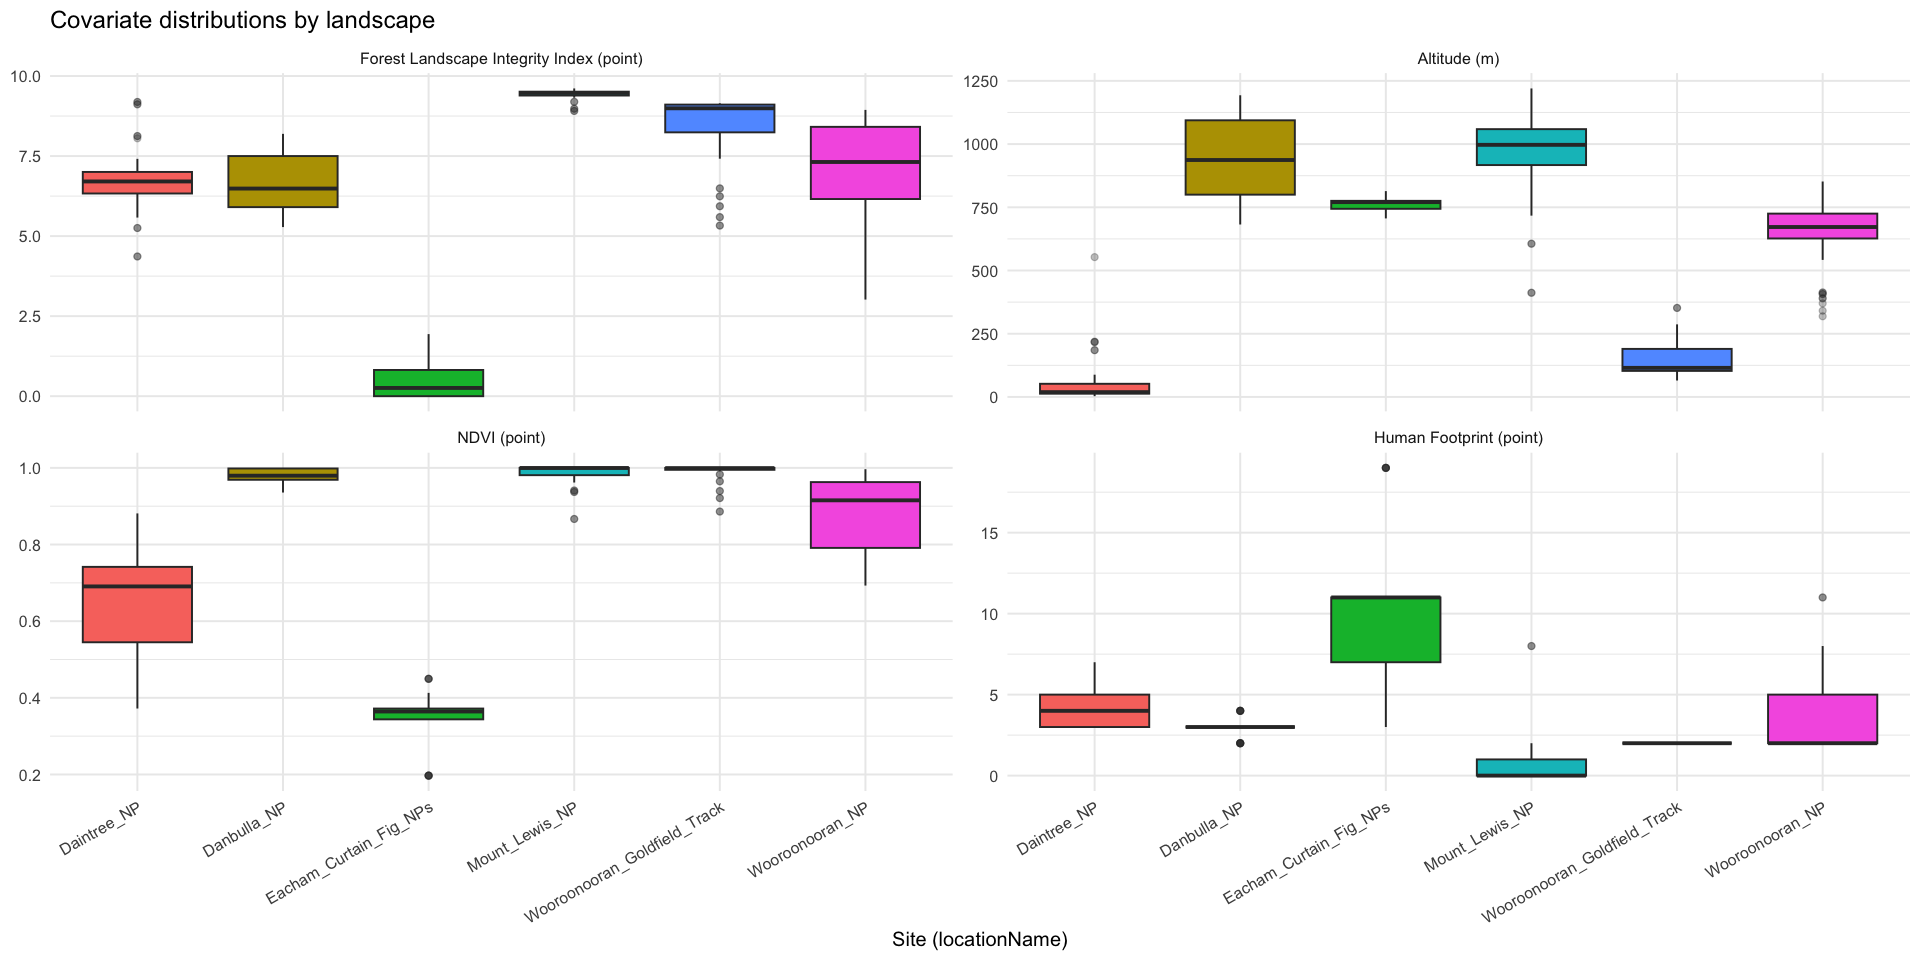

In [13]:

vars_box <- c("FLII_point", "altitude_point", "NDVI_point", "human_footprint_point")

covs_long <- covariates %>%
  tidyr::pivot_longer(
    all_of(vars_box),
    names_to = "variable",
    values_to = "value"
  ) %>%
  dplyr::mutate(
    variable = factor(
      variable,
      levels = vars_box,
      labels = c(
        "Forest Landscape Integrity Index (point)",
        "Altitude (m)",
        "NDVI (point)",
        "Human Footprint (point)"
      )
    )
  )

ggplot(covs_long, aes(x = locationName, y = value, fill = locationName)) +
  geom_boxplot(outlier.alpha = 0.3) +
  facet_wrap(~ variable, scales = "free_y", ncol = 2) +
  labs(
    x = "Site (locationName)",
    y = NULL,
    title = "Covariate distributions by landscape"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1),
    legend.position = "none"   # optional — remove legend if cluttered
  )


**Mount_Lewis_NP and Wooroonooran_Goldfield_Track** are high-elevation, high-integrity rainforest sites with very high NDVI.

**Daintree_NP and Danbulla_NP** are lower-elevation but still high-integrity.

**Eacham_Curtain_Fig_NPs** stands out as the only **disturbed** site — very low FLII, low NDVI, and the highest human footprint.

### 1.3.4 WildObs Data Integrity Check & Pre-processing

This block performs **data inspection, schema extraction, validation, and pre-processing** for the three WildObs resources: **deployments, observations, and covariates.**


In [14]:

# Define a helper function to summarise a dataset
dataset_summary <- function(df, name) {

  # Create a small tibble containing basic metadata about the dataset
  tibble(
    dataset = name,        # Name of the dataset (e.g. "observations")
    n_rows  = nrow(df),    # Total number of rows in the data frame
    n_cols  = ncol(df)     # Total number of columns in the data frame
  )
}

# Combine summary information for each dataset into a single table
bind_rows(
  dataset_summary(observations, "observations"),  # Summary of observations table
  dataset_summary(deployments, "deployments"),    # Summary of deployments table
  dataset_summary(covariates, "covariates")       # Summary of covariates table
) %>%
  print()   # Print the combined summary table to the console


# A tibble: 3 × 3
  dataset      n_rows n_cols
  <chr>         <int>  <int>
1 observations 130682     34
2 deployments     275     27
3 covariates      275    127



From the summary above, the observations, deployments, and covariates datasets contain 37, 27, and 83 fields, respectively. Although the deployments and covariates tables contain 27 and 83 fields respectively, not all fields are shared between them. To better understand their structural relationship, we compared the column names to identify common fields and those unique to each table.


In [15]:

# Identify column names that are shared between deployments and covariates
# These fields are typically used as identifiers or join keys
intersect(names(deployments), names(covariates)) %>%
  sort() %>%                                   # Sort alphabetically for readability
  kable(
    col.names = "Common Fields",
    caption   = "Fields Present in Both Deployments & Covariates"
  )

# Identify fields that exist only in the deployments table
# These describe deployment-specific metadata
setdiff(names(deployments), names(covariates)) %>%
  kable(col.names = "Only in Deployments")

# Identify fields that exist only in the covariates table
# These are typically environmental or derived variables
setdiff(names(covariates), names(deployments)) %>%
  kable(col.names = "Only in Covariates")

# Store field groupings explicitly for further use

# Sorted list of fields shared by both tables
common_fields <- sort(intersect(names(deployments), names(covariates)))

# Fields unique to the deployments table
only_deploy   <- sort(setdiff(names(deployments), names(covariates)))

# Fields unique to the covariates table
only_covs     <- sort(setdiff(names(covariates), names(deployments)))

# Determine the maximum number of fields across the three groups
# This is required so all columns in the final tibble have equal length
max_len <- max(
  length(common_fields),
  length(only_deploy),
  length(only_covs)
)

# Helper function to pad shorter vectors with NA values
# Ensures all vectors have the same length for tibble creation
pad <- function(x, n) {
  c(x, rep(NA, n - length(x)))
}

# Combine the three field groups into a single side-by-side comparison table
field_table <- tibble::tibble(
  common_fields        = pad(common_fields, max_len),
  only_in_deployments  = pad(only_deploy,   max_len),
  only_in_covariates   = pad(only_covs,     max_len)
)

# Print the final comparison table
print(field_table)



Table: Fields Present in Both Deployments & Covariates

|Common Fields    |
|:----------------|
|deploymentEnd    |
|deploymentGroups |
|deploymentID     |
|deploymentStart  |
|latitude         |
|locationID       |
|locationName     |
|longitude        |
|projectName      |
|source           |



|Only in Deployments         |
|:---------------------------|
|coordinateUncertainty       |
|setupBy                     |
|cameraID                    |
|cameraModel                 |
|cameraDelay                 |
|cameraHeight                |
|cameraDepth                 |
|cameraTilt                  |
|cameraHeading               |
|detectionDistance           |
|timestampIssues             |
|baitUse                     |
|featureType                 |
|habitat                     |
|deploymentTags              |
|deploymentComments          |
|multiSeason_deploymentGroup |



|Only in Covariates                     |
|:--------------------------------------|
|FLII_point                             |
|FLII_1km2                              |
|FLII_3km2                              |
|FLII_5km2                              |
|FLII_10km2                             |
|human_footprint_point                  |
|human_footprint_1km2                   |
|human_footprint_3km2                   |
|human_footprint_5km2                   |
|human_footprint_10km2                  |
|altitude_point                         |
|altitude_1km2                          |
|altitude_3km2                          |
|altitude_5km2                          |
|altitude_10km2                         |
|ecoregion_intactness_point             |
|ecoregion_intactness_1km2              |
|ecoregion_intactness_3km2              |
|ecoregion_intactness_5km2              |
|ecoregion_intactness_10km2             |
|mean_monthly_precipitation_point       |
|mean_monthly_precipitation_1km2

# A tibble: 117 × 3
   common_fields    only_in_deployments   only_in_covariates          
   <chr>            <chr>                 <chr>                       
 1 deploymentEnd    baitUse               altitude_10km2              
 2 deploymentGroups cameraDelay           altitude_1km2               
 3 deploymentID     cameraDepth           altitude_3km2               
 4 deploymentStart  cameraHeading         altitude_5km2               
 5 latitude         cameraHeight          altitude_point              
 6 locationID       cameraID              days_since_recent_fire_10km2
 7 locationName     cameraModel           days_since_recent_fire_1km2 
 8 longitude        cameraTilt            days_since_recent_fire_3km2 
 9 projectName      coordinateUncertainty days_since_recent_fire_5km2 
10 source           deploymentComments    days_since_recent_fire_point
# ℹ 107 more rows



Read schema to understand covariates and choose which to include in your model. Each schema includes a description, data type (*e.g.*, numeric or factor), spatial resolution, and constraints such as minimum and maximum values.


In [16]:

## Extract covariates schema from the data package

# Retrieve the Frictionless schema for the 'covariates' resource
# This schema defines the expected structure, types, and constraints
# for each covariate field (metadata, not the data itself)
covs_schema <- frictionless::get_schema(dp_list[[1]], "covariates")

## Convert schema to a tidy data frame

# Each field in the schema is stored as a nested list.
# Convert these field definitions into a tabular format for easier inspection.
covs_schema_df <- purrr::map_df(covs_schema$fields, ~{

  # Extract relevant schema attributes for each field,
  # using NA defaults where attributes are not defined
  tibble::tibble(
    name        = .x$name %||% NA,                     # Field (column) name
    description = .x$description %||% NA,              # Human-readable description
    type        = .x$type %||% NA,                      # Expected data type
    example     = as.character(.x$example %||% NA),    # Example value (if provided)
    required    = .x$constraints$required %||% NA,     # Whether the field is mandatory
    unique      = .x$constraints$unique %||% NA,       # Whether values must be unique
    enum        = paste(                                # Allowed values, if constrained
      .x$constraints$enum %||% NA,
      collapse = "|"
    )
  )
})

## Inspect the covariates schema

# Display the schema summary to quickly assess
# the number of fields and their declared constraints
glimpse(covs_schema_df)


Rows: 126
Columns: 7
$ name        <chr> "deploymentID", "locationID", "locationName", "latitude", …
$ description <chr> "Unique identifier of the deployment.", "Identifier of the…
$ type        <chr> "string", "string", "string", "number", "number", "datetim…
$ example     <chr> "dep1", "loc1", "Białowieża MRI 01", "52.7044", "23.8499",…
$ required    <lgl> TRUE, FALSE, FALSE, TRUE, TRUE, TRUE, TRUE, FALSE, TRUE, T…
$ unique      <lgl> TRUE, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ enum        <chr> "NA", "NA", "NA", "NA", "NA", "NA", "NA", "NA", "NA", "NA"…



This schema tells us **what must exist, what may exist, and what should be chosen**, making covariate selection a deliberate, defensible modelling step rather than a convenience decision.


In [17]:
## which variables are just characters?
unique(covs_schema_df$name[covs_schema_df$type == "string"])

[1] "deploymentID"           "locationID"             "locationName"          
[4] "deploymentGroups"       "Olson_global_ecoregion" "IBRAsubRegionName"     
[7] "IBRAbioRegionName"      "projectName"

In [18]:
## which variables are numeric?
unique(covs_schema_df$name[covs_schema_df$type == "number"])

[1] "latitude"                              
  [2] "longitude"                             
  [3] "FLII_point"                            
  [4] "FLII_1km2"                             
  [5] "FLII_3km2"                             
  [6] "FLII_5km2"                             
  [7] "FLII_10km2"                            
  [8] "human_footprint_point"                 
  [9] "human_footprint_1km2"                  
 [10] "human_footprint_3km2"                  
 [11] "human_footprint_5km2"                  
 [12] "human_footprint_10km2"                 
 [13] "altitude_point"                        
 [14] "altitude_1km2"                         
 [15] "altitude_3km2"                         
 [16] "altitude_5km2"                         
 [17] "altitude_10km2"                        
 [18] "ecoregion_intactness_point"            
 [19] "ecoregion_intactness_1km2"             
 [20] "ecoregion_intactness_3km2"             
 [21] "ecoregion_intactness_5km2"             
 [22] "ecoregion_intactness_10km2"            
 [23] "mean_monthly_precipitation_point"      
 [24] "mean_monthly_precipitation_1km2"       
 [25] "mean_monthly_precipitation_3km2"       
 [26] "mean_monthly_precipitation_5km2"       
 [27] "mean_monthly_precipitation_10km2"      
 [28] "mean_monthly_temperature_point"        
 [29] "mean_monthly_temperature_1km2"         
 [30] "mean_monthly_temperature_3km2"         
 [31] "mean_monthly_temperature_5km2"         
 [32] "mean_monthly_temperature_10km2"        
 [33] "nighttime_lights_point"                
 [34] "nighttime_lights_1km2"                 
 [35] "nighttime_lights_3km2"                 
 [36] "nighttime_lights_5km2"                 
 [37] "nighttime_lights_10km2"                
 [38] "human_population_density_point"        
 [39] "human_population_density_1km2"         
 [40] "human_population_density_3km2"         
 [41] "human_population_density_5km2"         
 [42] "human_population_density_10km2"        
 [43] "protected_areas_point"                 
 [44] "protected_areas_1km2"                  
 [45] "protected_areas_3km2"                  
 [46] "protected_areas_5km2"                  
 [47] "protected_areas_10km2"                 
 [48] "GEEBAM_fire_severity_2020_point"       
 [49] "GEEBAM_fire_severity_2020_1km2"        
 [50] "GEEBAM_fire_severity_2020_3km2"        
 [51] "GEEBAM_fire_severity_2020_5km2"        
 [52] "GEEBAM_fire_severity_2020_10km2"       
 [53] "GEEBAM_fire_severity_0_percent_1km2"   
 [54] "GEEBAM_fire_severity_1_percent_1km2"   
 [55] "GEEBAM_fire_severity_2_percent_1km2"   
 [56] "GEEBAM_fire_severity_3_percent_1km2"   
 [57] "GEEBAM_fire_severity_4_percent_1km2"   
 [58] "GEEBAM_fire_severity_5_percent_1km2"   
 [59] "GEEBAM_fire_severity_0_percent_3km2"   
 [60] "GEEBAM_fire_severity_1_percent_3km2"   
 [61] "GEEBAM_fire_severity_2_percent_3km2"   
 [62] "GEEBAM_fire_severity_3_percent_3km2"   
 [63] "GEEBAM_fire_severity_4_percent_3km2"   
 [64] "GEEBAM_fire_severity_5_percent_3km2"   
 [65] "GEEBAM_fire_severity_0_percent_5km2"   
 [66] "GEEBAM_fire_severity_1_percent_5km2"   
 [67] "GEEBAM_fire_severity_2_percent_5km2"   
 [68] "GEEBAM_fire_severity_3_percent_5km2"   
 [69] "GEEBAM_fire_severity_4_percent_5km2"   
 [70] "GEEBAM_fire_severity_5_percent_5km2"   
 [71] "GEEBAM_fire_severity_0_percent_10km2"  
 [72] "GEEBAM_fire_severity_1_percent_10km2"  
 [73] "GEEBAM_fire_severity_2_percent_10km2"  
 [74] "GEEBAM_fire_severity_3_percent_10km2"  
 [75] "GEEBAM_fire_severity_4_percent_10km2"  
 [76] "GEEBAM_fire_severity_5_percent_10km2"  
 [77] "HCAS_static_point"                     
 [78] "HCAS_static_1km2"                      
 [79] "HCAS_static_3km2"                      
 [80] "HCAS_static_5km2"                      
 [81] "HCAS_static_10km2"                     
 [82] "NDVI_point"                            
 [83] "NDVI_1km2"                             
 [84] "NDVI_3km2"                             
 [85] "NDVI_5km2"                             
 [86] "

In [19]:
## which variables are required?
unique(covs_schema_df$name[covs_schema_df$required == TRUE]) # anything that wont generate an NA

[1] "deploymentID"                          
 [2] "latitude"                              
 [3] "longitude"                             
 [4] "deploymentStart"                       
 [5] "deploymentEnd"                         
 [6] "FLII_point"                            
 [7] "FLII_1km2"                             
 [8] "FLII_3km2"                             
 [9] "FLII_5km2"                             
[10] "FLII_10km2"                            
[11] "human_footprint_point"                 
[12] "human_footprint_1km2"                  
[13] "human_footprint_3km2"                  
[14] "human_footprint_5km2"                  
[15] "human_footprint_10km2"                 
[16] "altitude_point"                        
[17] "altitude_1km2"                         
[18] "altitude_3km2"                         
[19] "altitude_5km2"                         
[20] "altitude_10km2"                        
[21] "ecoregion_intactness_point"            
[22] "ecoregion_intactness_1km2"             
[23] "ecoregion_intactness_3km2"             
[24] "ecoregion_intactness_5km2"             
[25] "ecoregion_intactness_10km2"            
[26] "mean_monthly_precipitation_point"      
[27] "mean_monthly_precipitation_1km2"       
[28] "mean_monthly_precipitation_3km2"       
[29] "mean_monthly_precipitation_5km2"       
[30] "mean_monthly_precipitation_10km2"      
[31] "mean_monthly_temperature_point"        
[32] "mean_monthly_temperature_1km2"         
[33] "mean_monthly_temperature_3km2"         
[34] "mean_monthly_temperature_5km2"         
[35] "mean_monthly_temperature_10km2"        
[36] "nighttime_lights_point"                
[37] "nighttime_lights_1km2"                 
[38] "nighttime_lights_3km2"                 
[39] "nighttime_lights_5km2"                 
[40] "nighttime_lights_10km2"                
[41] "human_population_density_point"        
[42] "human_population_density_1km2"         
[43] "human_population_density_3km2"         
[44] "human_population_density_5km2"         
[45] "human_population_density_10km2"        
[46] "protected_areas_point"                 
[47] "protected_areas_1km2"                  
[48] "protected_areas_3km2"                  
[49] "protected_areas_5km2"                  
[50] "protected_areas_10km2"                 
[51] "HCAS_static_point"                     
[52] "HCAS_static_1km2"                      
[53] "HCAS_static_3km2"                      
[54] "HCAS_static_5km2"                      
[55] "HCAS_static_10km2"                     
[56] "Olson_global_ecoregion"                
[57] "NDVI_point"                            
[58] "NDVI_1km2"                             
[59] "NDVI_3km2"                             
[60] "NDVI_5km2"                             
[61] "NDVI_10km2"                            
[62] "terrain_ruggedness_index_point"        
[63] "terrain_ruggedness_index_1km2"         
[64] "terrain_ruggedness_index_3km2"         
[65] "terrain_ruggedness_index_5km2"         
[66] "terrain_ruggedness_index_10km2"        
[67] "standardized_precipitation_index_point"
[68] "standardized_precipitation_index_1km2" 
[69] "standardized_precipitation_index_3km2" 
[70] "standardized_precipitation_index_5km2" 
[71] "standardized_precipitation_index_10km2"
[72] "HIF_point"                             
[73] "HIF_1km2"                              
[74] "HIF_3km2"                              
[75] "HIF_5km2"                              
[76] "HIF_10km2"                             
[77] "EII_point"                             
[78] "EII_1km2"                              
[79] "EII_3km2"                              
[80] "EII_5km2"                              
[81] "EII_10km2"                             
[82] "IBRAsubRegionName"                     
[83] "IBRAbioRegionName"                     
[84] NA


Finally, all spatially derived covariates include a link to access the online source where the spatial data was accessed to provide more information. This is currently missing but will be fixed soon ([see this issue on WildObs database for updates](https://github.com/WildObs/cam-DB/issues/239))


In [20]:

## whats the description of HCAS?
covs_schema_df$description[covs_schema_df$name == "HCAS_static_3km2"]

## Great, we know what the covariates are, we can remove the covs_schema
rm(covs_schema)

[1] "This variable represents the long-term (1988-2022) estimate of habitat condition across Australia, derived from the Habitat Condition Assessment System (HCAS v3.1). Condition values are calculated using a nationally consistent ecological model that incorporates vegetation structure, land use, connectivity, and degradation pressure, and are scaled from 0 to 1, where 1 = very high integrity and 0 = very low integrity. This variable has been calculated with a buffer around each deploymentID. This variable has been calculated with a 977.2 meter buffer around each deploymentID."


Merge covariates with deployments by all shared columns to avoid duplication. Both tables are indexed by deploymentID, but the tables share the following columns: `"deploymentID", "locationID", "locationName", "latitude", "longitude", "deploymentStart", "deploymentEnd", and "deploymentGroups"`.


In [21]:
## deployments and covaraites should both be indexed by deploymentID, make sure they match!
WildObsR::verify_col_match(deployments, covariates, col = "deploymentID") # full match!

# merge together based on shared cols so we have one less object to deal with
covariates = merge(deployments, covariates, by = names(covariates)[names(covariates) %in% names(deployments)])


[1] "All values from the column: deploymentID match! Proceed with further data wrangling"



Convert all datetime strings into POSIXct data class to ensure data is recognized in a date-time format. This is particularly critical for `deploymentStart` and `deploymentEnd` in the deployments and `eventStart` and `eventEnd` in the observations data resources.


In [22]:

## format date-time columns
covariates$deploymentEnd = as.POSIXct(covariates$deploymentEnd, format = "%Y-%m-%dT%H:%M:%S%z")
covariates$deploymentStart = as.POSIXct(covariates$deploymentStart, format = "%Y-%m-%dT%H:%M:%S%z")
observations$eventStart = as.POSIXct(observations$eventStart, format = "%Y-%m-%dT%H:%M:%S%z")
observations$eventEnd = as.POSIXct(observations$eventEnd, format = "%Y-%m-%dT%H:%M:%S%z")


Inspect deployment covariates and standardise any inconsistencies. A common field with potentially inconsistent values is the [deploymentTags](https://camtrap-dp.tdwg.org/data/#deployments.deploymentTags) field that captures additional deployment related information beyond the camtrapDP standard. This field is formatted using `key:value` pairs that can be extracted to new columns.

This section standardises and parses the deploymentTags field, which often stores additional user-defined metadata such as bait type or predator-management activity. Tags are cleaned, split into key–value pairs, reshaped into separate covariate columns, and merged back into the main covariates table. This transforms previously unstructured text metadata into proper categorical covariates that can be included in the analysis as fixed effects or grouping variables. This likely will become a function to be used in the WildObsR package ([see here for updates](https://github.com/WildObs/WildObsR/issues/93)).


In [23]:

## Inpsect deploymentTags, where additional information beyond camtrapDP standards may be stored.
unique(covariates$deploymentTags) # Standardize values

# Finds all rows where deploymentTags matches any of the messy or inconsistent versions in the list (e.g., missing bait:none, inconsistent spacing, inconsistent capitalization).

#	Replaces all those variations with one clean, standardised version:"bait:none | predatorManagement: No management"

covariates$deploymentTags[covariates$deploymentTags %in% c("lure:none | predatorManagement: No management",
                                               " | predatorManagement: No management",
                                               "lure:none | predatorManagement:no management",
                                               "lure:none | predatorManagement:No management"
                                               )] = "lure:none | predatorManagement: No management"


[1] "lure: none | predatorManagement: No management"


Expand deploymentTags into separate columns in the deployments data resource (*e.g.*, bait, predatorManagement) as new site-level covariates. You can also expand observationTags into separate columns in the observations data resource (*e.g.*, temperature) as new observation-level covariates.


In [24]:
## Extract all tags into separate columns in covaraites
covs_with_tags <- covariates %>%
  # create new cols to track original rows and split tags
  dplyr::mutate(
    row_id = dplyr::row_number(),  # To track original rows
    tag_list = stringr::str_split(deploymentTags, "\\s*\\|\\s*")
  ) %>%
  tidyr::unnest(tag_list) %>%
  # Remove blanks
  filter(!is.na(tag_list), tag_list != "") %>%
  # split  keys and values
  separate(tag_list, into = c("tag_key", "tag_value"), sep = ":", fill = "right") %>%
  dplyr::mutate(
    tag_key = str_trim(tag_key),
    tag_value = str_trim(tag_value)
  ) %>%
  pivot_wider(
    id_cols = row_id,
    names_from = tag_key,
    values_from = tag_value
  ) %>%
  right_join(
    covariates %>% dplyr::mutate(row_id = dplyr::row_number()),
    by = "row_id"
  ) %>%
  select(-row_id)

# inspect
table(covs_with_tags$lure)
table(covs_with_tags$predatorManagement)


none 
 275 


No management 
          275 


This tells us that **all 275 deployments share the same tag values**:

-   Every deployment was recorded with **bait:none**, meaning **no bait was used** anywhere in the study. This can also be inspected by checking the logical true/false column `baitUse`.

-   Every deployment also has **predatorManagement: No management**, meaning **no predator-control actions (e.g., trapping, poison, fencing) were active** during any deployment.


In [25]:
## save these extra column names that we will use later
tag_cols = setdiff(names(covs_with_tags), names(covariates))


### 1.3.5 Species selection

**Step 3: Species selection**

-   Select the species you are interested in. Can repeat the process of analyzing species occupancy for multiple species using for-loops. In this example we will select four species.

-   Understand the ecology of the species you have selected. An important consideration is the average home-range size of each species relative to the assumption of *independence across sites*. For example, if a species’ home range is larger than the average spacing between sampling sites and the same individual is detected across multiple sites, this violates a key assumption of the model ([see here for more information](https://doi.org/10.1111/ecog.07402)). WildObs provides a data set that includes species traits, including home-range sizes, which were extracted from the [`traitdata` R package](https://github.com/RS-eco/traitdata?tab=readme-ov-file) and matched with the WildObs species database.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/occupancy_practical_animals.png)

> **Source of the picture of each species:**
>
> Dingo: https://biocache.ala.org.au/occurrences/5ea25ebe-2e63-4b28-96e9-8dd98b80e55d  
> Feral Cat: https://biocache.ala.org.au/occurrences/5a1d30c2-96cf-4f7e-a832-60944583fca4  
> Lace Monitor: https://biocache.ala.org.au/occurrences/53c5d6e7-3b22-442d-a068-0ab9b2791bfe  
> Chowchilla: https://biocache.ala.org.au/occurrences/b98c136f-7455-44ea-879e-2ae0ca2db8ed

In [26]:
sp = c("Canis dingo",             # Dingo
       "Felis catus",             # Feral cat
       "Orthonyx spaldingii",     # Chowchilla
       "Varanus varius"           # Lace Monitor
       )


### 1.3.6 Spatial resampling

**Step 4: Spatial resampling**

Spatial resampling is the process of aggregating camera deployments and observations into spatially discrete sampling units. This process is achieved by creating a grid of hexagons covering a specific area, and aggregating deployments and observations per date. This process ensures comparability among landscapes, reduces spatial pseudo-replication, and, by using a sampling unit size larger than the species’ home range, ensures that occupancy is being measured, as opposed to habitat use.

For more information on spatial resampling for occupancy model, please see the method sections of Amir et al. (2022), Anderson et al. (2025), and Linkie (2020).

The WildObsR R library provides two functions to facilitate resampling: `WildObsR::spatial_hexagon_generator()` to generate the grid of hexagons and `WildObsR::resample_covariates_and_observations()` to use the grid of hexagons to resample the data.

-   First, using the home range sizes for each species, ensure sizes are converted to m² as the resampling scale.

-   Use the `WildObsR::spatial_hexagon_generator()` function to generate hexagonal sampling units at multiple scales (1 km², 3 km², 6 km², 65 km²) based on species home range.

-   Examine and summarise sampling efforts by inspecting important columns like number of deployments and hexagonal sampling units, duration of deployments, and calculating new columns like sampling effort, expressed as trap nights.

-   Importantly, the field [`deploymentGroups`](https://camtrap-dp.tdwg.org/data/#deployments.deploymentGroups) has been calculated through the WildObs data curation process to describe spatially (*i.e.*, within one landscape, denoted as [locationName](https://camtrap-dp.tdwg.org/data/#deployments.locationName)) and temporally (*i.e.*, 100 days maximum in duration) distinct sampling efforts (*i.e.*, surveys).

-   Remove deploymentGroups that don’t meet inclusion criteria (too short, too few sites, \>120 days, multiple landscapes, repeated deployments). This ensures robust surveys are included in the analysis and results wont be skewed by small sample sizes.

-   Keep only robust deployments and matching observations that fall within deploymentGroups of sufficent size.

-   Use the `WildObsR::resample_covariates_and_observations()` function to spatially resample covariates and observations across multiple spatial scales. This function changes the structure of the data in several important ways.

-   First, it removes any time-related information and summarizes observations per day. The function also calculates revised sampling effort per sampling unit (*i.e.*, rather than per deployment) to account for multiple deployments within a single sampling unit.

-   A new observation-level covariate, `numberDeploymentsActiveAtDate`, describes how many deployments were active within a sampling unit on each day and serves as a high-resolution observation-level covariate for sampling effort. You can also include additional observation-level covariates from the covariates table in the observations table (*e.g.*, `featureType`).

    -   For example, if two deployments placed on different features are resampled into the same sampling unit, you can include `featureType` to denote which deployment and corresponding feature generated the observation.

-   Finally, it is important to consider whether to aggregate the number of individuals detected per day by taking the **maximum** or the **sum** across all detections. For a full description of this function and its options, see the help page: `?WildObsR::resample_covariates_and_observations()`

**Species traits**

There is a built-in data WildObsR dataset called species_traits in which you can find some information about a species. Here, we care about the home range for species, as we need to use this information to make decisions on the spatial resampling.


In [27]:

library(WildObsR)

data("species_traits")

head(species_traits)

traits <- species_traits

binomial_verified,uri,phylum,class,order,family,genus,species,home_range_km2,home_range_source,AdultBodyMass_g,bodyMass_source,epbc_category,epbc_location
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<fct>,<chr>
Acanthagenys rufogularis,https://biodiversity.org.au/afd/taxa/8698c1d0-2079-477f-832a-0771c8df7cad,Chordata,Aves,Passeriformes,Meliphagidae,Acanthagenys,Acanthagenys rufogularis,NA,NA,44.700,10.1038/sdata.2015.61,not_listed,NA
Acanthiza apicalis,https://biodiversity.org.au/afd/taxa/500e1350-1d00-4f1c-b9d3-d02b949cdd47,Chordata,Aves,Passeriformes,Acanthizidae,Acanthiza,Acanthiza apicalis,NA,NA,7.250,10.1038/sdata.2015.61,not_listed,NA
Acanthiza chrysorrhoa,https://biodiversity.org.au/afd/taxa/aa581ac7-f29a-4e72-be0d-48a5e0a64de3,Chordata,Aves,Passeriformes,Acanthizidae,Acanthiza,Acanthiza chrysorrhoa,NA,NA,9.350,10.1038/sdata.2015.61,not_listed,NA
Acanthiza lineata,https://biodiversity.org.au/afd/taxa/7814eae1-111d-4016-aebb-bcd783fa3753,Chordata,Aves,Passeriformes,Acanthizidae,Acanthiza,Acanthiza lineata,NA,NA,7.320,10.1038/sdata.2015.61,vulnerable,SA
Acanthiza nana,https://biodiversity.org.au/afd/taxa/f27f902e-e7a7-4a3b-be0c-13310b16d008,Chordata,Aves,Passeriformes,Acanthizidae,Acanthiza,Acanthiza nana,NA,NA,6.475,10.1038/sdata.2015.61,not_listed,NA
Acanthiza pusilla,https://biodiversity.org.au/afd/taxa/62f6a29a-7b0c-4e5c-83ea-0074f99d133b,Chordata,Aves,Passeriformes,Acanthizidae,Acanthiza,Acanthiza pusilla,NA,NA,9.050,10.1038/sdata.2015.61,endangered,TAS


In [28]:

## check if species are present
setdiff(sp, traits$binomial_verified) # all are present!

## reduce to the relevant species
traits = traits[traits$binomial_verified %in% sp, ]

# Check for missing home-range values
anyNA(traits$home_range_km2) # true!
traits[, c("binomial_verified", "home_range_km2")]


character(0)

[1] TRUE

binomial_verified,home_range_km2
<chr>,<dbl>
Canis dingo,NA
Felis catus,5.88
Orthonyx spaldingii,NA
Varanus varius,NA



From the table above, home-range information is incomplete for several species. We only have reliable data for **Feral cat**, which typically remains within approximately 6 km of its home range. For dingo, lace monitor, and chowchilla, home-range values are currently unknown. We will need to identify suitable surrogate estimates to fill these gaps.

To proceed, we will apply surrogate values: 6 km for dingo, and 1 km for both lace monitor and chowchilla as our current best estimates. Dingoes have unusually large or variable home-range estimates. To avoid under-estimating their spatial scale, they are assigned the **maximum** available home-range value (6,000,000 m² in our subset of four species).

Species without home-range estimates (e.g., *Orthonyx spaldingii*, *Varanus varius*) are given a default of:

-   **1 km²** = **1,000,000 m²**

This ensures every species has a usable scale for spatial resampling.


In [29]:
# convert to m2
traits$home_range_m2 = ceiling(traits$home_range_km2 * 1e6 / 1e6) * 1e6 # but round to the nearest 1km2

# Make dingo home-ranges same as biggest option
traits$home_range_m2[traits$binomial_verified == "Canis dingo"] <-  max(traits$home_range_m2, na.rm = T)

# and all others default to 1km
traits$home_range_m2[is.na(traits$home_range_m2)] = 1e6

traits %>%
  select(binomial_verified, home_range_km2, home_range_m2) %>%
  arrange(desc(home_range_m2)) %>%
  print()


# A tibble: 4 × 3
  binomial_verified   home_range_km2 home_range_m2
  <chr>                        <dbl>         <dbl>
1 Canis dingo                  NA          6000000
2 Felis catus                   5.88       6000000
3 Orthonyx spaldingii          NA          1000000
4 Varanus varius               NA          1000000


In [30]:

# Create spatial hexagons based on species home-range scales

## Save this info as scales to resample
scales = unique(sort(traits$home_range_m2))

# scales should contain only: 1e6 (1 km2) and 6e6 (6 km2)
scales
# [1] 1e6 6e6

covs_cellIDs <- WildObsR::spatial_hexagon_generator(
  data   = covs_with_tags,
  scales = scales
)

### Inspect generated hexagon columns
hex_cols <- names(covs_cellIDs)[grepl("cellID", names(covs_cellIDs))]
hex_cols
# Expect: "cellID_1km2", "cellID_6km2"

length(unique(covs_cellIDs$cellID_1km2))
length(unique(covs_cellIDs$cellID_6km2))

# Summarise deploymentGroup robustness

surv_summary <- ddply(
  covs_cellIDs,
  .(deploymentGroups),
  summarize,
  num_su_1km = length(unique(cellID_1km2)),   # 1 km2 sampling units
  num_su_6km = length(unique(cellID_6km2)),   # 6 km2 sampling units
  num_land   = length(unique(locationName)),  # number of locations in the group
  dur = as.numeric(
    difftime(
      max(deploymentEnd),
      min(deploymentStart),
      units = "days"
    )
  )
)

# Calculate trap-nights (sampling effort)
surv_summary$trap_nights <- surv_summary$num_su_1km * surv_summary$dur

# Inspect (sorted)
surv_summary[order(surv_summary$trap_nights), ]


# Identify deploymentGroups to remove

# 1. low sampling effort
rm1 <- surv_summary$deploymentGroups[surv_summary$trap_nights < 100]

# 2. very long surveys (>120 days)
rm3 <- surv_summary$deploymentGroups[surv_summary$dur > 120]

# 3. multiple landscapes in one deploymentGroup (should be 1)
rm4 <- surv_summary$deploymentGroups[surv_summary$num_land > 1]

# 4. repeated deployments
rm5 <- unique(covs_cellIDs$deploymentGroups[
  duplicated(covs_cellIDs$deploymentID)
])

# Combine
rm <- unique(c(rm1, rm3, rm4, rm5))
rm


# Quantify loss of observations if removed
lost_pct <- round(
  nrow(observations[
    observations$deploymentID %in%
      covs_cellIDs$deploymentID[covs_cellIDs$deploymentGroups %in% rm],
  ]) / nrow(observations) * 100,
  3
)

lost_pct
# percentage of observations removed

# Apply filtering to covariates and observations

covs_cellIDs <- covs_cellIDs[
  !covs_cellIDs$deploymentGroups %in% rm,
]

observations <- observations[
  observations$deploymentID %in% covs_cellIDs$deploymentID,
]


# Result check

nrow(covs_cellIDs)
length(unique(covs_cellIDs$deploymentGroups))
length(unique(observations$deploymentID))

[1] 1e+06 6e+06

[1] "cellID_1km2" "cellID_6km2"

[1] 144

[1] 113

,deploymentGroups,num_su_1km,num_su_6km,num_land,dur,trap_nights
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
3,Eacham_Curtain_Fig_NPs_2022_Amir_WildObsID_0001,16,9,1,82.29579,1316.733
4,Mount_Lewis_NP_2022_Amir_WildObsID_0001,22,18,1,78.66123,1730.547
1,Daintree_NP_2022_Amir_WildObsID_0001,24,23,1,77.98822,1871.717
2,Danbulla_NP_2022_Amir_WildObsID_0001,21,18,1,92.99595,1952.915
5,Wooroonooran_Goldfield_Track_2022_Amir_WildObsID_0001,26,19,1,94.84572,2465.989
6,Wooroonooran_NP_2022_Amir_WildObsID_0001,35,26,1,89.13432,3119.701


character(0)

[1] 0

[1] 275

[1] 6

[1] 275

In [31]:

# Spatial resampling: aggregate covariates & observations
# This step aligns detections and covariates to spatial sampling units
# (hexagons), approximating species' home-range scales.
# Note: this step may take several minutes depending on dataset size.

# 1. Select columns to aggregate using MODE (categorical fields)
mode_cols_covs <- names(covs_cellIDs)[
  grepl("source|IBRAsubRegionName|GEEBAM", names(covs_cellIDs))
]
# These variables represent attributes where the most common value
# should be retained after resampling.


# 2. Choose how to aggregate multiple individuals per window
individuals <- "max"   # Alternatives: "sum"

# 3. Observation-level covariates (dynamic, detection-level)
obs_covs <- c(
  "baitUse",
  "featureType",
  "setupBy",
  "cameraHeight",
  "cameraModel"
)
# These vary between deployments and through time.


# 4. Run spatial resampling
start <- Sys.time()

resampled_data <- resample_covariates_and_observations(
  covs           = covs_cellIDs,
  obs            = observations,
  individuals    = individuals,
  mode_cols_covs = mode_cols_covs,
  obs_covs       = obs_covs
)

end <- Sys.time()
end - start   # runtime information


# 5. Inspect resampled results (correct scales only: 1km2, 6km2)
glimpse(resampled_data$spatially_resampled_covariates$cellID_1km2)
glimpse(resampled_data$spatially_resampled_covariates$cellID_6km2)

glimpse(resampled_data$spatially_resampled_observations$cellID_1km2)
glimpse(resampled_data$spatially_resampled_observations$cellID_6km2)

# Notes:
# - Numeric covariates are averaged across cameras in each hexagon.
# - Categorical covariates use MODE aggregation.
# - Observation table gains fields like:
#       totalIndividuals
#       numberDeploymentsActiveAtDate
#   which support occupancy/abundance modelling.


# 6. Link each species with its correct spatial scale
sp_scales <- data.frame(
  scientificName = traits$binomial_verified,
  home_range_m2  = traits$home_range_m2
)

# Add a friendly label: "1km2", "6km2", etc.
sp_scales$scale_name <- paste0(sp_scales$home_range_m2 / 1e6, "km2")

sp_scales

Time difference of 2.691955 mins

Rows: 144
Columns: 143
$ cellID_1km2                                <chr> "Eacham_Curtain_Fig_NPs_82_…
$ polygon_1km2                               <chr> "Eacham_Curtain_Fig_NPs_82_…
$ Avg_latitude                               <dbl> -17.29114, -17.28851, -17.2…
$ Avg_longitude                              <dbl> 145.6316, 145.6295, 145.629…
$ Avg_coordinateUncertainty                  <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ Avg_cameraDelay                            <dbl> 0.0, 0.0, 0.0, 0.0, 0.0, 0.…
$ Avg_cameraHeight                           <dbl> 0.3, 0.3, 0.3, 0.3, 0.3, 0.…
$ Avg_cameraTilt                             <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ Avg_FLII_point                             <dbl> 1.7080000, 0.4250000, 0.000…
$ Avg_FLII_1km2                              <dbl> 0.7362727, 0.6608000, 1.308…
$ Avg_FLII_3km2                              <dbl> 0.8721481, 1.0480800, 1.709…
$ Avg_FLII_5km2                              <dbl> 1.0952000, 1.0841951, 1.573…
$ Avg_FLII_10km2 

Rows: 113
Columns: 143
$ cellID_6km2                                <chr> "Eacham_Curtain_Fig_NPs_23_…
$ polygon_6km2                               <chr> "Eacham_Curtain_Fig_NPs_23_…
$ Avg_latitude                               <dbl> -17.28919, -17.28151, -17.2…
$ Avg_longitude                              <dbl> 145.6286, 145.6254, 145.614…
$ Avg_coordinateUncertainty                  <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ Avg_cameraDelay                            <dbl> 0.00, 0.00, 0.25, 0.00, 0.0…
$ Avg_cameraHeight                           <dbl> 0.3, 0.3, 0.3, 0.3, 0.3, 0.…
$ Avg_cameraTilt                             <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ Avg_FLII_point                             <dbl> 0.8834286, 0.8135714, 0.000…
$ Avg_FLII_1km2                              <dbl> 0.7892326, 1.2762613, 0.855…
$ Avg_FLII_3km2                              <dbl> 0.8976594, 1.4267705, 0.852…
$ Avg_FLII_5km2                              <dbl> 1.0307817, 1.3406190, 1.051…
$ Avg_FLII_10km2 

Rows: 33,592
Columns: 30
$ cellID_1km2                   <chr> "Eacham_Curtain_Fig_NPs_82_cellID_1km2_2…
$ observationID                 <chr> "CFRAG_01_bush_20221215_Z_Amir_triggerOb…
$ eventID                       <chr> "CFRAG_01_bush_20221215_Z_Amir_30min_eve…
$ scientificName                <chr> "Alectura lathami", "Blank", "Mammalia",…
$ behavior                      <chr> "", "", "", "", "", "", "", "", "", "", …
$ classifiedBy                  <chr> "Zachary Amir", "Zachary Amir", "Zachary…
$ observationComments           <chr> "", "", "", "", "", "", "", "", "", "", …
$ projectName                   <chr> "ZAmir_QLD_Wet_Tropics_2022_WildObsID_00…
$ taxonID                       <chr> "https://www.ncbi.nlm.nih.gov/taxonomy/8…
$ taxonRank                     <chr> "species", "", "class", "species", "spec…
$ vernacularNamesEnglish        <chr> "australian brush-turkey", "", "mammals"…
$ source                        <chr> "Z_Amir", "Z_Amir", "Z_Amir", "Z_Amir", …
$ observationLe

Rows: 30,360
Columns: 30
$ cellID_6km2                   <chr> "Eacham_Curtain_Fig_NPs_23_cellID_6km2_2…
$ observationID                 <chr> "CFRAG_01_bush_20221215_Z_Amir_triggerOb…
$ eventID                       <chr> "CFRAG_01_bush_20221215_Z_Amir_30min_eve…
$ scientificName                <chr> "Alectura lathami", "Blank", "Mammalia",…
$ behavior                      <chr> "", "", "", "", "", "", "", "", "", "", …
$ classifiedBy                  <chr> "Zachary Amir", "Zachary Amir", "Zachary…
$ observationComments           <chr> "", "", "", "", "", "", "", "", "", "", …
$ projectName                   <chr> "ZAmir_QLD_Wet_Tropics_2022_WildObsID_00…
$ taxonID                       <chr> "https://www.ncbi.nlm.nih.gov/taxonomy/8…
$ taxonRank                     <chr> "species", "", "class", "species", "spec…
$ vernacularNamesEnglish        <chr> "australian brush-turkey", "", "mammals"…
$ source                        <chr> "Z_Amir", "Z_Amir", "Z_Amir", "Z_Amir", …
$ observationLe

scientificName,home_range_m2,scale_name
<chr>,<dbl>,<chr>
Canis dingo,6e+06,6km2
Felis catus,6e+06,6km2
Orthonyx spaldingii,1e+06,1km2
Varanus varius,1e+06,1km2



### 1.3.7 Detection matrix

**Step 5: Prepare matrices**

For each species (*i.e.*, in a for-loop):

-   Select the right spatial resampling scale based on home range data previously collected from the [`traitdata` R package](https://github.com/RS-eco/traitdata?tab=readme-ov-file).

-   The spatial resampling function will add the spatial scale to the sampling unit name to reflect the resampled scale. Therefore, to work across multiple scales, one must standardise sampling unit names to something simple like `cellID`.

-   Additional simple covariates can be derived from more complex covaraites that have many levels. For example, `featureType` contains [several enumerated classes](https://camtrap-dp.tdwg.org/data/#deployments.featureType), but can be simply reduced to a two-level variable of on or off-trails based on the enumerated values types. Including fixed effect covaraites with fewer levels often improves modelling performance.

-   WildObs calculates many **site-level covariates** across multiple spatial scales, including point values for the individual deployment coordinates, and in circular buffers around camera deployments covering areas of 1, 3, 5, and 10 km2. Unless you are particularly interested in how the same variable may affect wildlife occupancy across different spatial scales, one should thin the site covariates to the spatial scale that most closely matches the spatial resampling and home range scale. This is also a useful time to think critically about the covariates included in the analysis, since the analysis will be simplified by only selecting site-level covariates that will be useful for testing hypotheses or determining a best fitting model.

-   After site-level covariates are selected, select **observation covariates** from the spatialy resampled observations (*e.g.*, `numberDeploymentsActiveAtDate`, `trailStatus`, etc.). These covariates will vary through time and per detection. Therefore, these covariates must be found in the observations, not covariates, table.

-   Determine the structure of the **detection history matrices** you will create:

    -   First, you must determine the *maximum duration* of the matrix (i.e., number of columns), and its recommended to not exceed 100 days to satisfy the population closure assumption of the model.

    -   Next, you must determine the *sampling window duration* which is the number of days that fit into one column in the detection history matrix. Larger intervals (*e.g.*, 7-10 days) are typically better for rare species with very low detections, while shorter values (*e.g.*, 2-5 days) are better for frequently detected species.

        -   The goal here is to increase detection probability to enhance model performance.

    -   Finally, determine if you want to use *all* sampling units in the resampled data, or only locationNames (*i.e.*, large landscapes such as a national park) where the species was detected.

        -   Limiting the data to locationNames where the species was detected will improve model performance since the model will estimate non-zero occupancy for all sampling units even if we know the species is absent from a particular landscape. However, the species may be present but have very low detection probability, so it may be worth including locationNames with zero detections if there is strong rationale for inclusion.

-   Put together, the information you had just collated into the `WildObsR::matrix_generator()` function. This function produces detection history matrices for multiple species and multiple resampling scales and ensures that the site-level and observation-level covaraites are properly aligned to facilitate an occupancy analysis.

    -   The `WildObsR::matrix_generator()` function contains an additional paramater called `type`, where you can specify if you want to create a detection history matrix (using detection-non-detection data) for occupancy modelling or a count history matrix (using count data) for abundance modelling. Abundance modelling is beyond the scope of this tutorial, so we will set `type == "occupancy"`.

**Step 6: Build modelling objects**

-   For **occupancy models**: extract the detection history matrix, site-level and observation-level covariates form the `WildObsR::matrix_generator()` function and save them as an `unmarked::unmarkedFrameOccu` (UMF). This is a particular data structure formatted to work with occupancy models in the unmarked R package, thus facilitating easy analysis.

-   For multiple species, you can store each UMF in a list to save space in your global environment. Can format the list as one UMF per species with the name of the species saved in the name of the element in the list.


In [32]:
# Required arguments (defined once)
dur <- 50                   # maximum sampling duration
w <- 5                      # sampling window duration
all_locationNames <- FALSE  # only include locationNames where species were detected

# Build species + scale table
stopifnot(
  exists("traits"),
  all(c("binomial_verified", "home_range_m2") %in% names(traits))
)

sp_scales <- traits %>%
  dplyr::select(scientificName = binomial_verified, home_range_m2) %>%
  dplyr::mutate(
    scale_name = paste0(home_range_m2 / 1e6, "km2")
  )

## storage objects
vars_only <- list()
errors    <- list()

# Loop over species
for (i in seq_len(nrow(sp_scales))) {

  sp    <- sp_scales$scientificName[i]
  scale <- sp_scales$scale_name[i]
  key   <- paste0("cellID_", scale)

  tryCatch({

    # Extract resampled data for this scale
    resamp_obs  <- resampled_data$spatially_resampled_observations[[key]]
    resamp_covs <- resampled_data$spatially_resampled_covariates[[key]]

    if (is.null(resamp_obs) || is.null(resamp_covs)) {
      stop(paste("Scale", scale, "not available for species", sp))
    }

    ## Standardise cellID name
    names(resamp_obs)[grepl("cellID", names(resamp_obs))]   <- "cellID"
    names(resamp_covs)[grepl("cellID", names(resamp_covs))] <- "cellID"

    # Observation covariates: trail / off-trail
    resamp_obs$trailStatus <- ifelse(
      grepl("road|trail", resamp_obs$featureType, ignore.case = TRUE),
      "onTrail", "offTrail"
    )

    # Choose covariates at closest spatial scale
    target_scale <- suppressWarnings(as.numeric(gsub("km2", "", scale)))
    if (is.na(target_scale)) target_scale <- 0

    km2_cols <- names(resamp_covs)[stringr::str_detect(names(resamp_covs),
                                                       "_\\d+km2$|_point$")]

    scale_info <- tibble::tibble(col = km2_cols) %>%
      mutate(
        scale_val = ifelse(grepl("_point$", col),
                           0,
                           as.numeric(stringr::str_extract(col, "\\d+(?=km2$)"))),
        base = stringr::str_remove(col, "_(point|\\d+km2)$")
      )

    closest_cols <- scale_info %>%
      group_by(base) %>%
      slice_min(abs(scale_val - target_scale), n = 1, with_ties = FALSE) %>%
      ungroup()

    # Tag + mode columns
    tag_cols  <- intersect(c("bait", "predatorManagement"), names(resamp_covs))
    mode_cols <- names(resamp_covs)[grepl("^mode_", names(resamp_covs))]

    site_covs_keep <- unique(c(
      tag_cols,
      closest_cols$col,
      "deploymentGroups",
      "locationName"
    ))

    obs_covs_keep <- unique(c(
      "numberDeploymentsActiveAtDate",
      "trailStatus",
      mode_cols
    ))

    ## ensure landscapes are removed if NOT warning to be included in matrix
    if(!all_locationNames){
      # grab deployments w/ detections
      sp_deps = resamp_obs$cellID[which(resamp_obs$scientificName == sp)]
      # and grab the corresponding landscapes
      sp_land = unique(resamp_covs$locationName[resamp_covs$cellID %in% sp_deps])
      # thin covs to only those landsacpes
      resamp_covs = resamp_covs[resamp_covs$locationName %in% sp_land, ]
      # and thin observatiosn to match
      resamp_obs = resamp_obs[resamp_obs$cellID %in% resamp_covs$cellID, ]
    } # end locationName thinning conditon

    # Run matrix generator (extraction only)
    mat <- matrix_generator(
      obs = resamp_obs, covs = resamp_covs,
      dur = dur, w = w,
      site_covs = site_covs_keep,
      obs_covs  = obs_covs_keep,
      all_locationNames = all_locationNames,
      scientificNames   = sp,
      type = "occupancy",
      individuals = "max"        # doesn't matter for occupancy, only abundance
    )

    # Save extracted pieces
    vars_only[[sp]] <- list(
      detection_matrix = mat[[1]]$detection_matrix,
      site_covariates  = mat[[1]]$site_level_covariates,
      obs_covariates   = mat[[1]]$observation_level_covariates
    )

  }, error = function(e) {

    ## Store error for review
    errors[[sp]] <<- conditionMessage(e)

  })

} # end loop


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no data in the site-level covariate: Avg_GEEBAM_fire_severity_0_percent_5km2 & Avg_GEEBAM_fire_severity_4_percent_5km2 & Avg_GEEBAM_fire_severity_5_percent_5km2 so it has been removed from the matrix generation function.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the site-level covariate: predatorManagement so it has been removed from the matrix generation function.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the observation-level covariate: mode_source & mode_IBRAsubRegionName for the species: Canis dingo so it has been removed from the matrix generation function for this species.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no data in the site-level covariate: Avg_GEEBAM_fire_severity_0_percent_5km2 & Avg_GEEBAM_fire_severity_4_percent_5km2 & Avg_GEEBAM_fire_severity_5_percent_5km2 so it has been removed from the matrix generation function.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the site-level covariate: predatorManagement so it has been removed from the matrix generation function.”


...

Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the site-level covariate: predatorManagement so it has been removed from the matrix generation function.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the observation-level covariate: mode_source & mode_IBRAsubRegionName for the species: Orthonyx spaldingii so it has been removed from the matrix generation function for this species.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no data in the site-level covariate: Avg_GEEBAM_fire_severity_0_percent_1km2 & Avg_GEEBAM_fire_severity_1_percent_1km2 & Avg_GEEBAM_fire_severity_4_percent_1km2 & Avg_GEEBAM_fire_severity_5_percent_1km2 so it has been removed from the matrix generation function.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the site-level covariate: predatorManagement so it has been removed from the matrix generation function.”


Warning message in matrix_generator(obs = resamp_obs, covs = resamp_covs, dur = dur, :
“There was no variation in the observation-level covariate: mode_source & mode_IBRAsubRegionName for the species: Varanus varius so it has been removed from the matrix generation function for this species.”



You can see there are two repeating warnings for all the four species:

**Warning 1:** “There was no variation in the site-level covariate: bait & predatorManagement”

**Warning 2**: “There was no variation in the observation-level covariate: mode_source & mode_IBRAsubRegionName”

For warning 1, since all the camera deployments had bait = "none", and had predatorManagement = "No management", so they are two constant variable have no modelling values, so WildObsR automatically drops it. This is good for us.

For warning 2, similar to warning 1, all observations came from the same data provider (`source`) and all observations were in the same IBRAsubRegionName after resampling, again, no variation, they can't be used as covariates, so WildObsR automatically drops them.


In [33]:
# Summary of what succeeded / failed
names(vars_only)
errors

[1] "Canis dingo"         "Felis catus"         "Orthonyx spaldingii"
[4] "Varanus varius"

list()


We see four species:

```         
"Canis dingo"         "Felis catus"         "Orthonyx spaldingii" "Varanus varius"
```

This means:

1.  the resampling worked
2.  the matrix generator worked
3.  did not lose any species

Also, we see the empty

```         
list()
```

which means

1.  There were no failures

2.  Every species successfully produced data

3.  No missing scale issues

4.  No resampling errors

5.  No deployment group issues blocking the code

## 1.4 Occupancy model with WildObs data

### 1.4.1 Prepare UMF

First, we need to generate an UMF for each of the species we select.


In [34]:
# Extract UMFs per species, using the values gathered from the matrix_generator() function

# Repeat per species
umf_list = list()
for(i in 1:length(vars_only)){
  ## select data from one species
  dat = vars_only[[i]]
  ## and store in UMF object
  umf = unmarked::unmarkedFrameOccu(y = dat$detection_matrix,
                                    siteCovs = dat$site_covariates,
                                    obsCovs = dat$obs_covariates)
  # save in the list
  umf_list[[i]] = umf
  names(umf_list)[i] = names(vars_only)[i]
} # end per species
rm(i, dat, umf)

Warning message:
“siteCovs contains characters. Converting them to factors.”


Warning message:
“obsCovs contains characters. Converting them to factors.”


Warning message:
“siteCovs contains characters. Converting them to factors.”


Warning message:
“obsCovs contains characters. Converting them to factors.”


Warning message:
“siteCovs contains characters. Converting them to factors.”


Warning message:
“obsCovs contains characters. Converting them to factors.”


Warning message:
“siteCovs contains characters. Converting them to factors.”


Warning message:
“obsCovs contains characters. Converting them to factors.”



> The warnings you see are a normal part of the modelling process. They occur when a categorical variable needs to be converted into a model-ready format. The system handles this automatically to keep the models reliable.


In [35]:
## inspect results
names(umf_list) # all species present

# select which species we will analyze
# sp_occu = "Canis dingo"
# sp_occu = "Varanus varius"
sp_occu = "Felis catus"
# sp_occu = "Orthonyx spaldingii"

[1] "Canis dingo"         "Felis catus"         "Orthonyx spaldingii"
[4] "Varanus varius"


We successfully made the occupancy umf for each species. Lets inspect the umf object for a single species, *`r sp_occu`*.


In [36]:
# select one umf
umf = umf_list[[sp_occu]]

# inspect data
summary(umf)

unmarkedFrame Object

94 sites
Maximum number of observations per site: 10 
Mean number of observations per site: 9.82 
Sites with at least one detection: 30 

Tabulation of y observations:
   0    1 <NA> 
 838   85   17 

Site-level covariates:
                                     cellID       predatorManagement
 Daintree_NP_108_cellID_6km2_2022_Z_Amir: 1   No management:94      
 Daintree_NP_109_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_123_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_124_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_125_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_134_cellID_6km2_2022_Z_Amir: 1                         
 (Other)                                :88                         
                      polygon_6km2
 Daintree_NP_108_cellID_6km2: 1   
 Daintree_NP_109_cellID_6km2: 1   
 Daintree_NP_123_cellID_6km2: 1   
 Daintree_NP_124_cellID_6km2: 1   
 Daintree_NP_125_cellID_6km

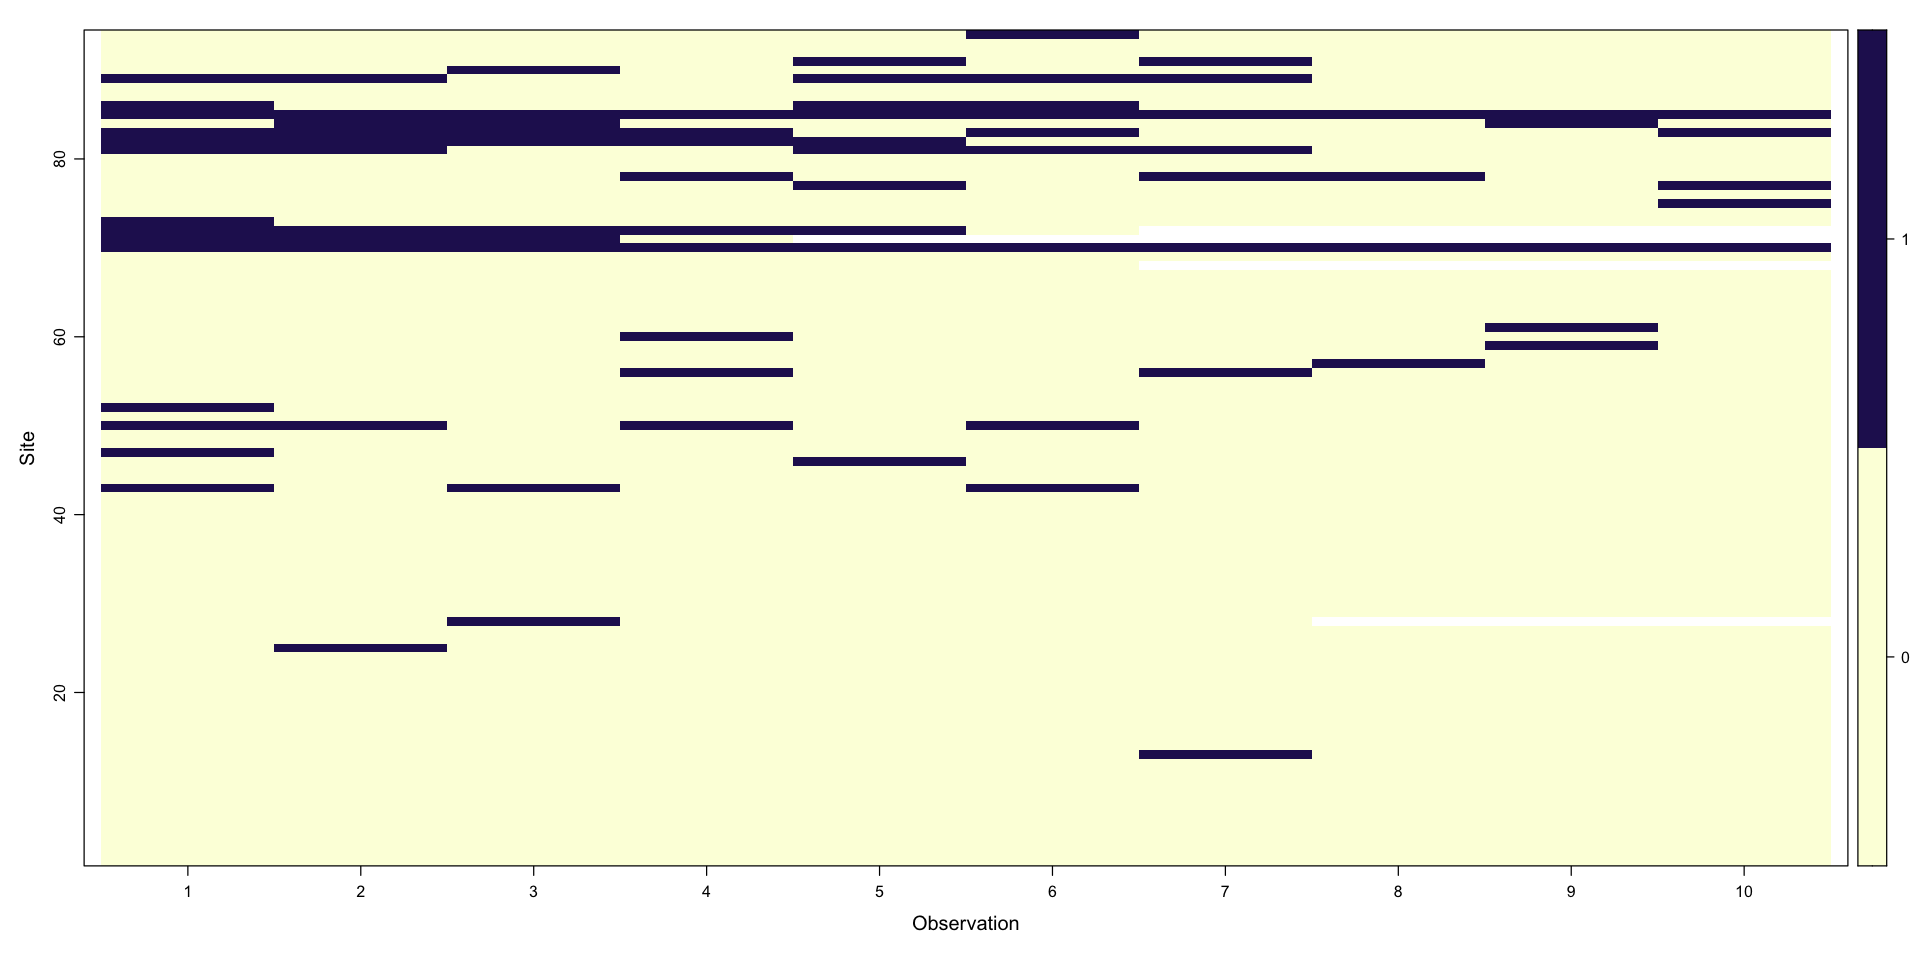

In [37]:
# visualize
plot(umf)


This heatmap shows detections across sites (rows) and repeated observation periods (columns). Most sites have many non-detections (light cells), with detections occurring sporadically, which is typical for wildlife monitoring data, especially for rare species. A small number of sites show repeated detections across multiple observations, indicating higher or more consistent activity at those locations.

### 1.4.2 Null model for Occupancy model

Creating occupancy models using the unmarked R package follows a similar syntax to writing linear models in R. We will use the `unmarked::occu()` function to create occupancy models. The formula is specifid as a double sided formula describing detection probability first (left side) and then occupancy (right side), where tildas (\~) denote each formula. Before we begin adding covariates to our occupancy models, its wise to generate a *null model* that uses no covariates in either formula as the basis of comparison.


In [38]:
####### Basic hand-written cat occupancy models & visualization

# create a null model w/ no variables on the detection (left) or occupancy (right) formula
mod1 <- unmarked::occu(~1 ~1, data = umf)

out <- capture.output({
  cat("=== Null occupancy model ===\n")
  print(summary(mod1))
  cat("\nAIC:", mod1@AIC)
})

cat(out, sep = "\n")


=== Null occupancy model ===

Call:
unmarked::occu(formula = ~1 ~ 1, data = umf)

Occupancy (logit-scale):
 Estimate    SE     z P(>|z|)
   -0.703 0.226 -3.11  0.0019

Detection (logit-scale):
 Estimate    SE    z  P(>|z|)
   -0.919 0.139 -6.6 4.16e-11

AIC: 468.4304 
Number of sites: 94

$state
              Estimate        SE         z     P(>|z|)
(Intercept) -0.7028989 0.2262888 -3.106203 0.001895064

$det
             Estimate        SE         z      P(>|z|)
(Intercept) -0.918884 0.1392594 -6.598361 4.157286e-11


AIC: 468.4304



This null occupancy model estimates that `r sp_occu` occupy about X% of sites, with a per-occasion detection probability of roughly Y%, indicating imperfect detection. The low detection probability explains why many occupied sites have few or no detections. This model provides a baseline against which more complex models with detection and environmental covariates can be compared.

### 1.4.3 Detection models with alternative detection covariates


In [39]:

## Detection models with alternative detection covariates
## Goal: identify the best-supported detection structure before modelling occupancy

# Detection varies with sampling effort only
det1 <- unmarked::occu(~ numberDeploymentsActiveAtDate ~ 1, data = umf)

# Detection varies with camera placement (on/off trail)
det2 <- unmarked::occu(~ trailStatus ~ 1, data = umf)

# Detection varies with both trail placement and sampling effort
det3 <- unmarked::occu(~ trailStatus + numberDeploymentsActiveAtDate ~ 1, data = umf)

## Compare AIC values across detection models
aic_det <- data.frame(
  model = c("effort only", "trail status", "trail + effort"),
  AIC   = c(det1@AIC, det2@AIC, det3@AIC)
)

aic_det

model,AIC
<chr>,<dbl>
effort only,461.5835
trail status,455.9461
trail + effort,447.0645



These results show that **detection probability is strongly influenced by trail placement & sampling effort**, and **combining trail status with sampling effort provides a substantially better fit** than either variable alone.

The **trail + effort** model has the lowest AIC (ΔAIC \> 8 compared to the others), indicating strong support for using both covariates in the detection component of the occupancy model.

### 1.4.4 Select state variables

The `WildObsR::matrix_generator()` function has already standardized numeric covariates to have a mean of zero and a standard deviation of 1 to ensure comparable model outputs. Before feeding the resampled covariates into the function, we also limited to our spatial scale of interest to match the home-range size of our species.


In [40]:
# these are our options to include
summary(umf@siteCovs)

                                     cellID       predatorManagement
 Daintree_NP_108_cellID_6km2_2022_Z_Amir: 1   No management:94      
 Daintree_NP_109_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_123_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_124_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_125_cellID_6km2_2022_Z_Amir: 1                         
 Daintree_NP_134_cellID_6km2_2022_Z_Amir: 1                         
 (Other)                                :88                         
                      polygon_6km2
 Daintree_NP_108_cellID_6km2: 1   
 Daintree_NP_109_cellID_6km2: 1   
 Daintree_NP_123_cellID_6km2: 1   
 Daintree_NP_124_cellID_6km2: 1   
 Daintree_NP_125_cellID_6km2: 1   
 Daintree_NP_134_cellID_6km2: 1   
 (Other)                    :88   
                                        deploymentGroups
 Daintree_NP_2022_Amir_WildObsID_0001           :23     
 Danbulla_NP_2022_Amir_WildObsID_0001           :18   


### 1.4.5 Compare alternative random‐effect structures for the state (occupancy) process

We can include random-intercept effects in both the occupancy and deteciton formula of occupancy models to account for variation that we are not necessarily interested in. For example, we may care about how a species occupancy varies along an elevation gradient, but are less interested in how it varies per landscape. However, we are aware there could be unmeasured variation between landscapes that should be accounted for in our modelling process.


In [41]:

## Detection structure is held constant (trailStatus + sampling effort)

## Compare alternative random‐effect structures for the state model

state_re1 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate
  ~ (1 | deploymentGroups),
  data = umf
)

state_re2 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate
  ~ (1 | locationName),
  data = umf
)

cat(
  "\n Random effects comparison (lower AIC = better):\n",
  "------------------------------------------------\n",
  "Random intercept: deploymentGroups | AIC =", round(state_re1@AIC, 2), "\n",
  "Random intercept: locationName     | AIC =", round(state_re2@AIC, 2), "\n"
)



 Random effects comparison (lower AIC = better):
 ------------------------------------------------
 Random intercept: deploymentGroups | AIC = 439.93 
 Random intercept: locationName     | AIC = 439.93 



Both random‐effects structures (**deploymentGroups** and **locationName**) produce **identical AIC values (443.18)**, indicating **no difference in model support** between the two grouping factors. In this case, either random effect is statistically equivalent, and the choice should be guided by **study design and interpretability** rather than model fit.

We therefore used a random intercept for locationName, as cameras within the same location are likely to share common ecological context (e.g. habitat, management history, and accessibility). This is because each landscape only contained one deploymentGroup, but when combining multiple datasets together, this could vary substantially!

### 1.4.6 Hypothesis-driven occupancy models


In [42]:

## Detection formula is fixed based on earlier AIC comparison:
##   ~ trailStatus + numberDeploymentsActiveAtDate
## Random effect is fixed at locationName
## Each model tests ONE ecological hypothesis

## gather all variables in a vector
occ_vars = c("Avg_HCAS_static_5km2", "Avg_human_population_density_5km2",
             "Avg_NDVI_5km2", "Avg_FLII_5km2", "Avg_altitude_5km2")

## H1: HCAS
## Hypothesis: species occupancy decreases with increasing HCAS
h1 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate       # detection model
  ~ (1 | locationName) + Avg_HCAS_static_5km2,        # state (occupancy) model
  data = umf
)

## H2: Human population density
## Hypothesis: species occupancy increases with human population density
h2 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate   # detection model
  ~ (1 | locationName) +
    Avg_human_population_density_5km2,             # state model
  data = umf
)

## H3: NDVI
## Hypothesis: species occupancy decreases with increasing vegetation greenness
h3 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate   # detection model
  ~ (1 | locationName) + Avg_NDVI_5km2,             # state model
  data = umf
)

## H4: Forest Landscape Integrity Index (FLII)
## Hypothesis: species occupancy increases with higher forest integrity
h4 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate   # detection model
  ~ (1 | locationName) + Avg_FLII_5km2,             # state model
  data = umf
)

## H5: altiide
## Hypothesis: species occupancy increases with higher altitude
h5 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate         # detection model
  ~ (1 | locationName) + Avg_altitude_5km2,             # state model
  data = umf
)


In [43]:

## Summarise model support using AIC
## Lower AIC = stronger support

## Create a compact comparison table
hypotheses <- data.frame(
  Hypothesis = c(
    "HCAS (expected negative)",
    "Human population density (expected positive)",
    "NDVI (expected negative)",
    "Forest integrity – FLII (expected positive)",
    "Altitude (expected positive)"
  ),
  AIC = c(
    h1@AIC,   # AIC for HCAS model
    h2@AIC,   # AIC for human population model
    h3@AIC,   # AIC for NDVI model
    h4@AIC,   # AIC for FLII model
    h5@AIC    # AIC for elev model
  )
)

## Order models from best to worst support
hypotheses[order(hypotheses$AIC), ]


,Hypothesis,AIC
,<chr>,<dbl>
3,NDVI (expected negative),438.6957
2,Human population density (expected positive),441.6475
1,HCAS (expected negative),441.7276
5,Altitude (expected positive),441.8323
4,Forest integrity – FLII (expected positive),441.9244



All five habitat hypotheses have **similar AIC values (ΔAIC \< 4)**, indicating **no strong evidence that any single covariate clearly outperforms the others** in explaining `r sp_occu` occupancy at this scale. NDVI has the lowest AIC and is therefore *marginally* best supported, but the difference is too small to claim a meaningful advantage. Practically, this suggests that `r sp_occu` occupancy is **weakly influenced by multiple correlated landscape features rather than driven by one dominant variable**, and model choice should be guided by **ecological plausibility and parsimony**, not AIC alone.


In [44]:
## before creating multi-variate models, ensure covariates are NOT correlated!
## grab the relevant variables
var_dat = umf@siteCovs[, occ_vars]
## compute a correlation matrix
cor_mat = cor(var_dat, use = "complete.obs")
## determine a threshold
thresh <- 0.7
# get upper triangle only (avoid duplicates + diagonal)
high_cor <- which(abs(cor_mat) >= thresh &
                  upper.tri(cor_mat),
                  arr.ind = TRUE)
# return variable names + correlation values
data.frame(
  var1 = rownames(cor_mat)[high_cor[,1]],
  var2 = colnames(cor_mat)[high_cor[,2]],
  correlation = cor_mat[high_cor]
)

var1,var2,correlation
<chr>,<chr>,<dbl>
Avg_HCAS_static_5km2,Avg_NDVI_5km2,0.8028487
Avg_HCAS_static_5km2,Avg_FLII_5km2,0.7887112
Avg_NDVI_5km2,Avg_FLII_5km2,0.7147785



Before creating multi-variate models, its important to ensure that covariates are not strongly correlated with each other. In this case, we are using a cutoff of `r thresh` to ensure we include covariates that are clearly distinguishable from each other. In the print out above, we can see that HCAS is strongly correlated with NDVI and FLII, which are also strongly correlated with each other. Therefore, we would not include these variables together in the same multi-variate model.


In [45]:
## Multi-variate state model: forest integrity + human pressure
## Tests whether combining NDVI and human population density improves
## explanatory power beyond single-covariate models
multi1 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate       # detection process
  ~ (1 | locationName)                                # spatial random effect
    + Avg_NDVI_5km2                                   # forest integrity
    + Avg_human_population_density_5km2,              # human pressure
  data = umf
)

summary(multi1)
multi1@AIC   # AIC is worse than the NDVI-only model,
             # indicating worse additional support for the combined model

## try combining NDVI and altitude
multi2 <- unmarked::occu(
  ~ trailStatus + numberDeploymentsActiveAtDate       # detection process
  ~ (1 | locationName)                                # spatial random effect
    + Avg_NDVI_5km2                                   # forest integrity
    + Avg_altitude_5km2,                              # elevatoion
  data = umf
)

summary(multi2)
multi2@AIC   # AIC is a tad better than the NDVI-only model,


Call:
unmarked::occu(formula = ~trailStatus + numberDeploymentsActiveAtDate ~ 
    (1 | locationName) + Avg_NDVI_5km2 + Avg_human_population_density_5km2, 
    data = umf)

Occupancy (logit-scale):
Random effects:
       Groups        Name Variance Std.Dev.
 locationName (Intercept)    0.821    0.906

Fixed effects:
                                  Estimate    SE       z P(>|z|)
(Intercept)                       -0.85322 0.532 -1.6047  0.1086
Avg_NDVI_5km2                      0.86348 0.517  1.6689  0.0951
Avg_human_population_density_5km2 -0.00787 0.376 -0.0209  0.9833

Detection (logit-scale):
                              Estimate    SE      z P(>|z|)
(Intercept)                    -9.0013 26.63 -0.338 0.73535
trailStatusoffTrail - onTrail   6.9654 26.63  0.262 0.79366
trailStatusonTrail              8.8334 26.63  0.332 0.74013
numberDeploymentsActiveAtDate   0.0641  0.02  3.213 0.00131

AIC: 440.694 
Number of sites: 94



[1] 440.694


Call:
unmarked::occu(formula = ~trailStatus + numberDeploymentsActiveAtDate ~ 
    (1 | locationName) + Avg_NDVI_5km2 + Avg_altitude_5km2, data = umf)

Occupancy (logit-scale):
Random effects:
       Groups        Name Variance Std.Dev.
 locationName (Intercept)    0.764    0.874

Fixed effects:
                  Estimate    SE      z P(>|z|)
(Intercept)         -0.850 0.520 -1.635  0.1021
Avg_NDVI_5km2        1.019 0.540  1.886  0.0593
Avg_altitude_5km2   -0.356 0.457 -0.779  0.4359

Detection (logit-scale):
                              Estimate      SE      z P(>|z|)
(Intercept)                     -9.409 33.3301 -0.282 0.77772
trailStatusoffTrail - onTrail    7.374 33.3306  0.221 0.82491
trailStatusonTrail               9.243 33.3327  0.277 0.78155
numberDeploymentsActiveAtDate    0.064  0.0199  3.208 0.00134

AIC: 440.0809 
Number of sites: 94



[1] 440.0809


The unmarked R package has a number of useful tools for ranking competing models. We will use the `unmarked::fitList()` function to organize models for model selection, ensuring we specify which is the null model and point of comparison. Then we will use the `unmarked::modSel()` function create a table containing all model parameter effect sizes and AIC scores to enable an easy comparison across all models.


In [46]:
## Model comparison using AIC
## Combine all candidate models (detection, random effects, habitat hypotheses)
mods <- fitList(
  # null model first
  "null"               = mod1,

  # Detection structure
  "effort"             = det1,
  "trails"             = det2,
  "trails_and_effort"  = det3,

  # Random-effect structures
  "location_RE"        = state_re2,

  # State (occupancy) hypotheses
  "HCAS"               = h1,
  "human"              = h2,
  "ndvi"               = h3,
  "flii"               = h4,
  "ndvi_and_human"     = multi1,
  "ndvi_and_elev"      = multi2
)

## Rank models by AIC
mod_select <- modSel(mods)@Full

## Inspect key AIC results
mod_select[, c("model", "nPars", "AIC", "delta", "cumltvWt")]


,model,nPars,AIC,delta,cumltvWt
,<chr>,<int>,<dbl>,<dbl>,<dbl>
8,ndvi,6,438.6957,0.000000,0.3256371
5,location_RE,5,439.9287,1.233038,0.5014227
11,ndvi_and_elev,7,440.0809,1.385172,0.6643327
10,ndvi_and_human,7,440.6940,1.998331,0.7842279
7,human,6,441.6475,2.951821,0.8586589
6,HCAS,6,441.7276,3.031873,0.9301697
9,flii,6,441.9244,3.228696,0.9949781
4,trails_and_effort,5,447.0645,8.368817,0.9999379
3,trails,4,455.9461,17.250408,0.9999964



NDVI is the top‐ranked model, with the multivariate model combining NDVI and human population density performing almost as well (ΔAIC \< 1), indicating that both vegetation greenness and overall human population centers are strongly supported predictors of `r sp_occu` occupancy. Models including HCAS and those differing only by random‐effect structure receive some support (ΔAIC ≈ 1) but are clearly less informative than NDVI or human population density. HCAS adds little explanatory power (ΔAIC \> 2), but does not improve model fit. In contrast, detection‐only models based on effort or trail use perform very poorly (ΔAIC ≫ 8), confirming that `r sp_occu` occupancy in this system is driven primarily by landscape vegetation condition rather than detectability alone.


In [47]:

### Generate prediction data for key habitat covariates ----

# Create a sequence of human population values across the observed range
newd_human <- data.frame(
  Avg_human_population_density_5km2 = seq(
    from = min(umf@siteCovs$Avg_human_population_density_5km2),
    to   = max(umf@siteCovs$Avg_human_population_density_5km2),
    length.out = 100
  )
)

# Create a sequence of NDVI values across the observed range
newd_ndvi <- data.frame(
  Avg_NDVI_5km2 = seq(
    from = min(umf@siteCovs$Avg_NDVI_5km2),
    to   = max(umf@siteCovs$Avg_NDVI_5km2),
    length.out = 100
  )
)

### Predict occupancy across gradients ----

# Predict occupancy as a function of human
predict_human <- predict(
  h2,                 # human state model
  type       = "state",
  newdata    = newd_human,
  appendData = TRUE,
  re.form    = NA     # average across random-effect levels
)

predict_human$key_var <- "human_pop"
names(predict_human)[5] <- "simulated_cov"

# Predict occupancy as a function of NDVI
predict_ndvi <- predict(
  h3,                 # NDVI state model
  type       = "state",
  newdata    = newd_ndvi,
  appendData = TRUE,
  re.form    = NA
)

predict_ndvi$key_var <- "NDVI"
names(predict_ndvi)[5] <- "simulated_cov"

### Combine predictions for plotting ----

predict_df <- rbind(predict_human, predict_ndvi)

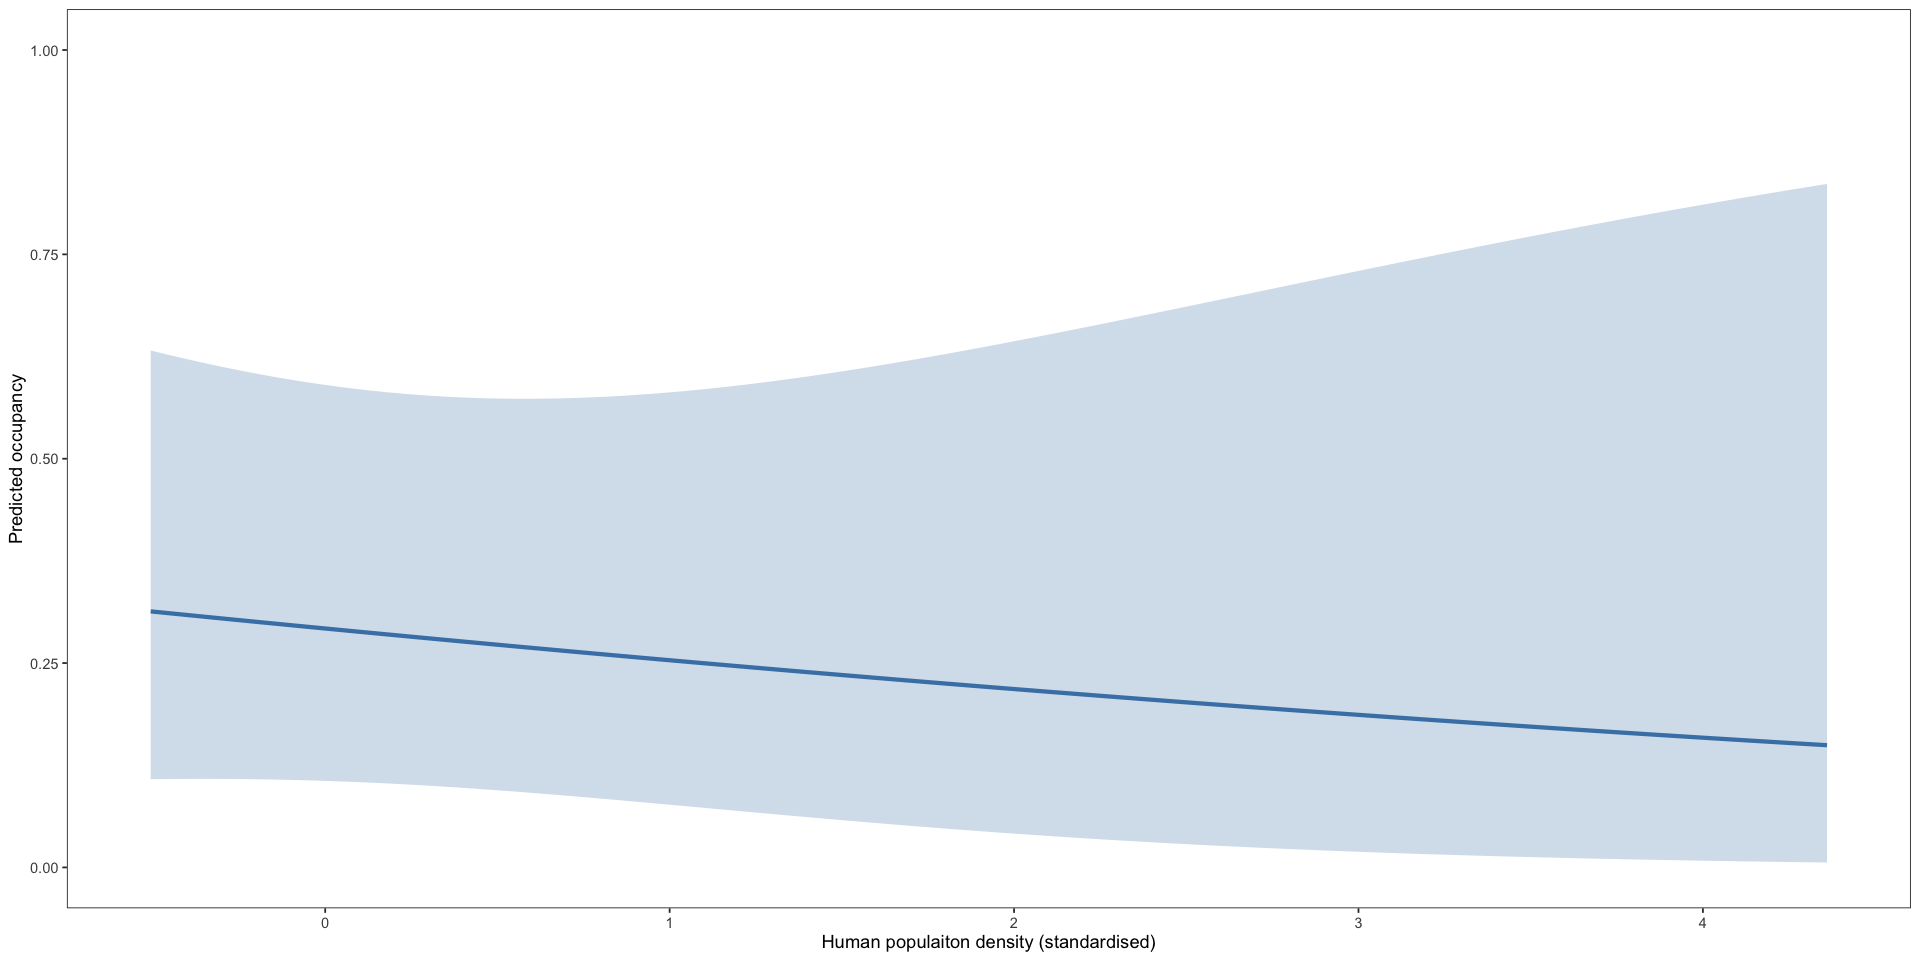

In [48]:

### Visualise predicted occupancy responses=

# human_pop response
ggplot(
  predict_df[predict_df$key_var == "human_pop", ],
  aes(x = simulated_cov, y = Predicted)
) +
  geom_line(color = "steelblue", linewidth = 1.2) +
  geom_ribbon(
    aes(ymin = lower, ymax = upper),
    fill  = "steelblue",
    alpha = 0.25
  ) +
  coord_cartesian(ylim = c(0, 1)) +
  theme_test() +
  labs(
    x = "Human populaiton density (standardised)",
    y = "Predicted occupancy"
  )



This plot shows a mildly negative relationship between human population density and predicted occupancy. As human population density increases, the probability of occupancy lowers steadily, though the confidence interval widens due to limited sampling in areas with many people. The shaded band indicates uncertainty around the prediction, which is wider at higher popualtion density values and narrows slightly as human population density decreases improves.


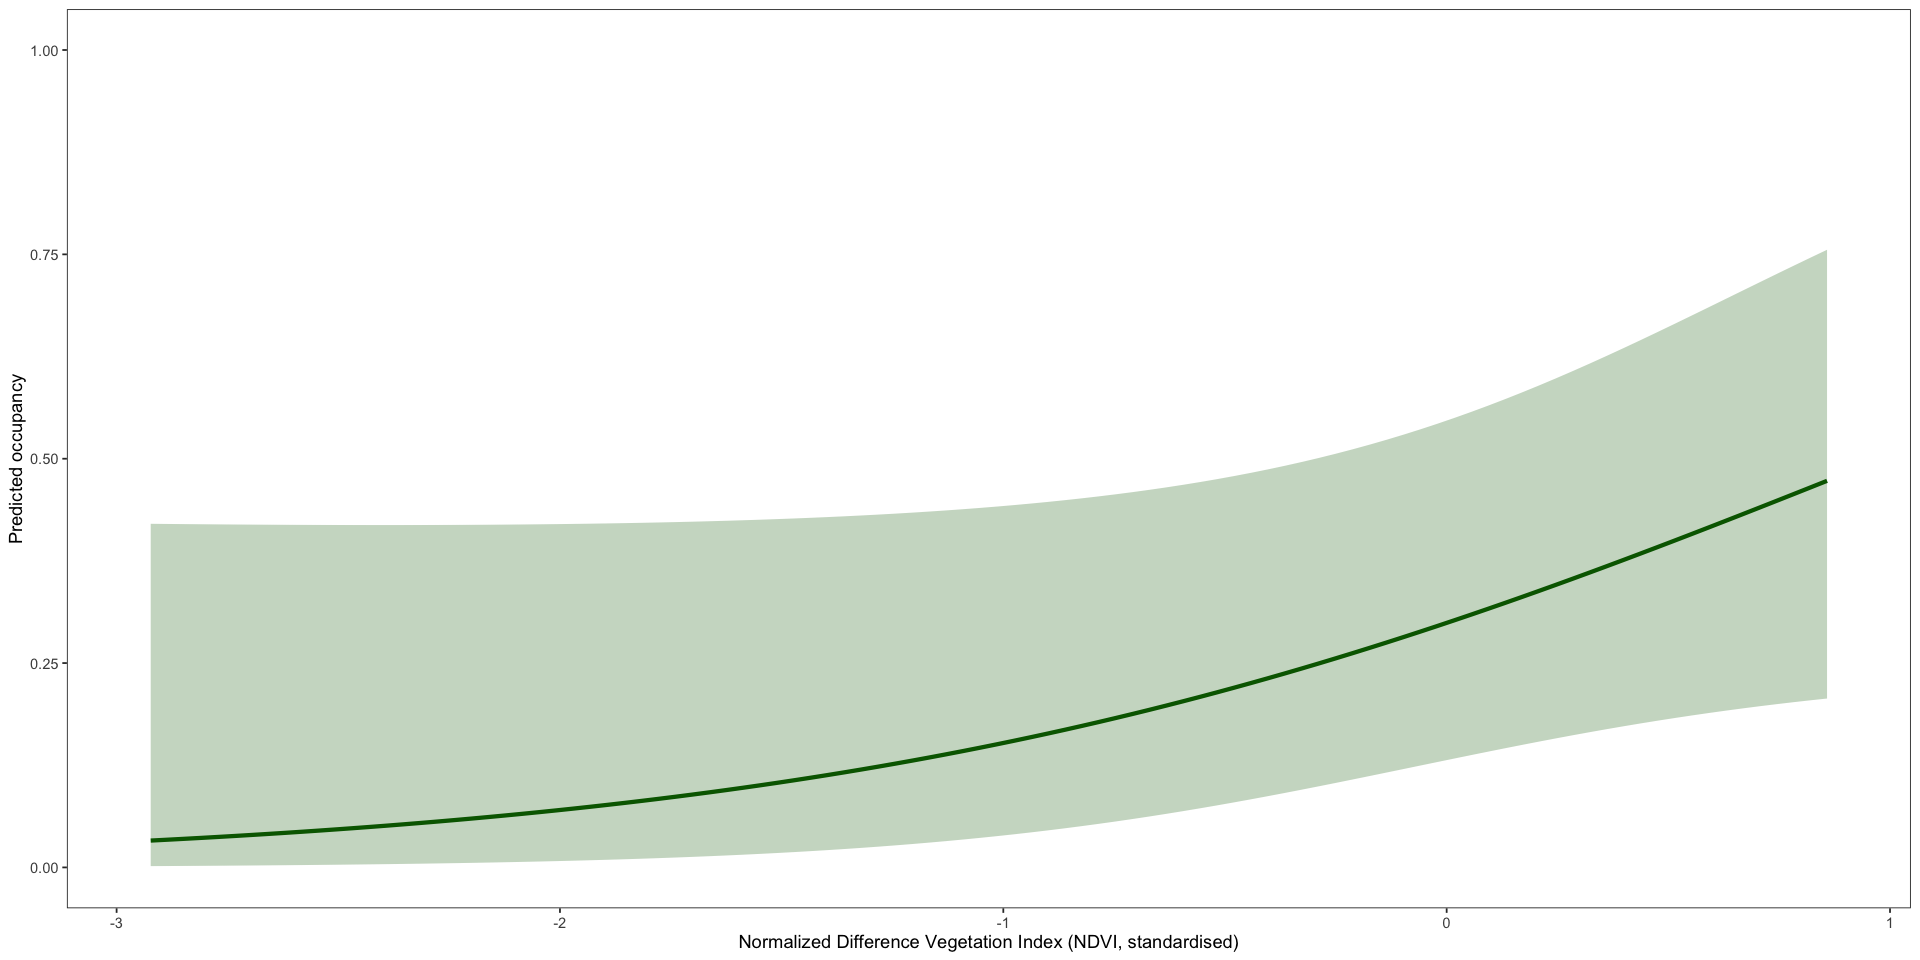

In [49]:

# NDVI response
ggplot(
  predict_df[predict_df$key_var == "NDVI", ],
  aes(x = simulated_cov, y = Predicted)
) +
  geom_line(color = "darkgreen", linewidth = 1.2) +
  geom_ribbon(
    aes(ymin = lower, ymax = upper),
    fill = "darkgreen",
    alpha = 0.25
  ) +
  coord_cartesian(ylim = c(0, 1)) +
  theme_test() +
  labs(
    x = "Normalized Difference Vegetation Index (NDVI, standardised)",
    y = "Predicted occupancy"
  )



This plot shows a strong positive relationship between NDVI and predicted occupancy. Occupancy is very low in areas with low vegetation greenness and increases sharply as NDVI rises, indicating a preference for more productive or densely vegetated habitats. The shaded confidence band reflects uncertainty in the predictions, which is larger at lower NDVI values and narrows slightly at higher vegetation levels.

And, that's pretty much it for the simple stuff!

if you made it this far, you may also be interested in how

we iterate this process for many species... but stay tuned for more!

# References

Nakashima, Y. (2020). Potentiality and limitations of N‐mixture and Royle‐Nichols models to estimate animal abundance based on noninstantaneous point surveys. *Population Ecology*, *62*(1), 151-157.

Amir, Z., Bruce, T., & Contributors. (2024). WildObsR: Professional tools for camera trap data access, management, and analysis in R. R package version 0.1.0. <https://github.com/WildObs/WildObsR>

Fiske, I., & Chandler, R. (2011). Unmarked: an R package for fitting hierarchical models of wildlife occurrence and abundance. *Journal of statistical software*, *43*, 1-23.

Amir, Z., Moore, J. H., Negret, P. J., & Luskin, M. S. (2022). Megafauna extinctions produce idiosyncratic Anthropocene assemblages. *Science Advances*, *8*(42), eabq2307.

Linkie, M. (2020). Managing threatened ungulates in logged-primary forest mosaics in Malaysia. *PLoS One*, *15*(12), e0243932.

Anderson, S. E., Amir, Z., Bruce, T., & Luskin, M. S. (2025). Range‐Wide Camera Trapping for the Australian Cassowary Reveals Habitat Associations With Rainfall and Forest Quality. *Ecology and Evolution*, *15*(6), e71464.

M. Rayan D., M. Linkie, Managing threatened ungulates in logged-primary forest mosaics in Malaysia. *PLOS ONE* **15**, e0243932 (2020).

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_section_break.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).

<div align="center">

**Our Partner**

</div>

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/updated_ourpartner_2025.png)

## How to cite this Notebook

Zhao, X. Y., & Amir, Z. (2026). *Single-Species Single-Season Occupancy Model - Practical* (Version 1.0) [Computational notebook]. Zenodo. <https://doi.org/10.5281/zenodo.19552244>

# **How to Cite EcoCommons**

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2026. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)